# Experiment Outputs Dashboard

This notebook discovers experiment outputs and plots each artifact type in separate sections for clean comparison across runs.

In [1]:
from __future__ import annotations

import gc
import json
from datetime import datetime
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)

In [2]:
KNOWN_ARTIFACTS = {
    "assignments.parquet",
    "per_document_utility.parquet",
    "pt_experiment.csv",
    "summary.json",
    "memory_summary.json",
    "full_run.parquet",
    "optimized_run.parquet",
    "profile_catalog.csv",
    "sampled_score_pairs.parquet",
    "metrics_long.csv",
    "metrics_wide.csv",
    "ranking_summary.csv",
    "run_metadata.json",
}

BASE_OUTPUT_DIR = (Path.cwd().parent / "matryoshka_optimization_codebase" / "outputs").resolve()
EXPORT_ROOT = (Path.cwd() / "exports").resolve()

print("Base outputs dir:", BASE_OUTPUT_DIR)
print("Export root:", EXPORT_ROOT)

Base outputs dir: /home/franchini/Master-Thesis/matryoshka_optimization_codebase/outputs
Export root: /home/franchini/Master-Thesis/analysis_viz/exports


In [3]:
def _is_excluded_path(path: Path, excluded_paths: list[str]) -> bool:
    parts = {p.lower() for p in path.parts}
    return any(excluded in parts for excluded in excluded_paths)


def _available_columns(path: Path) -> list[str]:
    suffix = path.suffix.lower()
    if suffix == ".parquet":
        return list(pq.ParquetFile(path).schema.names)
    if suffix == ".csv":
        return list(pd.read_csv(path, nrows=0).columns)
    return []


def _safe_read(path: Path, columns: list[str] | None = None):
    suffix = path.suffix.lower()
    try:
        if suffix in {".parquet", ".csv"}:
            selected = None
            if columns:
                available = set(_available_columns(path))
                selected = [column for column in columns if column in available]
                if not selected:
                    selected = None
            if suffix == ".parquet":
                return pd.read_parquet(path, columns=selected), None
            return pd.read_csv(path, usecols=selected), None
        if suffix == ".json":
            with open(path, "r", encoding="utf-8") as f:
                return json.load(f), None
        return None, f"Unsupported extension: {suffix}"
    except Exception as exc:
        return None, str(exc)


def _artifact_schema(path: Path) -> dict[str, Any]:
    try:
        if path.suffix.lower() == ".parquet":
            parquet = pq.ParquetFile(path)
            return {"rows": int(parquet.metadata.num_rows), "columns": list(parquet.schema.names)}
        if path.suffix.lower() == ".csv":
            # Reading only the header avoids materializing large CSV tables.
            return {"rows": None, "columns": list(pd.read_csv(path, nrows=0).columns)}
        if path.suffix.lower() == ".json":
            data, error = _safe_read(path)
            return {"keys": sorted(data.keys())} if not error and isinstance(data, dict) else {"error": error}
    except Exception as exc:
        return {"error": str(exc)}
    return {}


class LazyArtifactMapping:
    """Load one artifact on demand and never retain its DataFrame in the bundle."""

    def __init__(self, run_path: Path, kind: str):
        self.run_path = Path(run_path)
        self.kind = kind

    def load(self, name: str, columns: list[str] | None = None, default=None):
        path = self.run_path / name
        if not path.exists():
            return default
        data, error = _safe_read(path, columns=columns)
        if error:
            print(f"Could not load {path}: {error}")
            return default
        if self.kind == "table" and isinstance(data, pd.DataFrame):
            return data
        if self.kind == "json" and isinstance(data, dict):
            return data
        return default

    def get(self, name: str, default=None):
        return self.load(name, default=default)


def infer_experiment_type(artifact_names: set[str]) -> str:
    if "assignments.parquet" in artifact_names or "per_document_utility.parquet" in artifact_names:
        return "matryoshka_run"
    if {"metrics_long.csv", "metrics_wide.csv"}.intersection(artifact_names):
        return "side_quest_benchmark"
    if "pt_experiment.csv" in artifact_names and "summary.json" not in artifact_names:
        return "side_quest_benchmark"
    return "generic_experiment"


def discover_runs(base_output_dir: Path) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    if not base_output_dir.exists():
        return pd.DataFrame(columns=["run_name", "run_path", "experiment_type", "artifact_count", "artifacts"])

    excluded_paths = ["models", "embedding_checkpoints"]
    for run_dir in sorted(p for p in base_output_dir.rglob("*") if p.is_dir()):
        if _is_excluded_path(run_dir, excluded_paths):
            continue

        artifact_paths = [p for p in run_dir.iterdir() if p.is_file() and p.name in KNOWN_ARTIFACTS]
        if not artifact_paths:
            continue

        artifact_names = {p.name for p in artifact_paths}
        rows.append(
            {
                "run_name": run_dir.name,
                "run_path": str(run_dir),
                "experiment_type": infer_experiment_type(artifact_names),
                "artifact_count": len(artifact_names),
                "artifacts": sorted(artifact_names),
            }
        )

    return pd.DataFrame(rows).sort_values(["experiment_type", "run_name"]).reset_index(drop=True) if rows else pd.DataFrame(
        columns=["run_name", "run_path", "experiment_type", "artifact_count", "artifacts"]
    )


def load_run_artifacts(run_path: str | Path) -> dict[str, Any]:
    run_path = Path(run_path)
    schema = {
        artifact: _artifact_schema(run_path / artifact)
        for artifact in KNOWN_ARTIFACTS
        if (run_path / artifact).exists()
    }
    return {
        "run_name": run_path.name,
        "run_path": run_path,
        "tables": LazyArtifactMapping(run_path, "table"),
        "json": LazyArtifactMapping(run_path, "json"),
        "errors": {},
        "schema": schema,
    }


def _load_table(bundle: dict[str, Any], name: str, columns: list[str] | None = None):
    return bundle["tables"].load(name, columns=columns)


def build_manifest_with_schema(manifest: pd.DataFrame) -> pd.DataFrame:
    if manifest.empty:
        return manifest

    rows = []
    for _, row in manifest.iterrows():
        bundle = load_run_artifacts(row["run_path"])
        table_row_counts = {
            name: meta.get("rows")
            for name, meta in bundle["schema"].items()
            if "rows" in meta
        }
        key_columns = {
            name: meta.get("columns", [])[:8]
            for name, meta in bundle["schema"].items()
            if "columns" in meta
        }
        load_errors = {
            name: meta["error"]
            for name, meta in bundle["schema"].items()
            if meta.get("error")
        }
        rows.append(
            {
                **row.to_dict(),
                "table_row_counts": table_row_counts,
                "key_columns": key_columns,
                "load_errors": load_errors,
            }
        )
    return pd.DataFrame(rows)


def _first_existing_col(df: pd.DataFrame, candidates: list[str]) -> str | None:
    cols = {c.lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in cols:
            return cols[cand.lower()]
    return None


NON_METRIC_COLUMNS = {
    "name", "run", "system", "model", "model_id", "model_type", "dimension",
    "profile", "profile_name", "docno", "qid", "rank", "cost_bytes", "utility",
}

STATISTICAL_COLUMN_MARKERS = (
    "p-value", "p_value", "pvalue", "pval", "significant", "significance",
    "reject", "better", "worse", "improved", "degraded", "stderr", "std_err",
    "std error", "stddev", "variance", "ci", "confidence", "test", "correction",
)


def _is_statistical_or_nonmetric_column(column: str) -> bool:
    name = str(column).strip().lower()
    compact = name.replace(" ", "_")
    if compact in NON_METRIC_COLUMNS:
        return True
    if name.endswith(" +") or name.endswith(" -"):
        return True
    return any(marker in name for marker in STATISTICAL_COLUMN_MARKERS)


def _evaluation_metric_cols(df: pd.DataFrame) -> list[str]:
    return [
        c for c in df.columns
        if pd.api.types.is_numeric_dtype(df[c]) and not _is_statistical_or_nonmetric_column(str(c))
    ]


def _format_count(value: int | float) -> str:
    return f"{int(value):,}".replace(",", " ")


def _short_run_label(name: str) -> str:
    label = str(name)
    label = label.replace("profile_", "")
    label = label.replace("_run", "")
    label = label.replace("_embedding", "")
    return label


def _assignment_profile_summary(bundle: dict[str, Any]) -> tuple[pd.Series, pd.DataFrame]:
    """Aggregate assignment counts and costs in bounded-memory batches."""
    path = Path(bundle["run_path"]) / "assignments.parquet"
    if not path.exists():
        return pd.Series(dtype="int64"), pd.DataFrame()

    available = _available_columns(path)
    profile_col = next((c for c in ["profile", "profile_name", "assigned_profile", "name"] if c in available), None)
    cost_col = next((c for c in ["cost_bytes", "cost"] if c in available), None)
    if profile_col is None:
        return pd.Series(dtype="int64"), pd.DataFrame()

    columns = [profile_col] + ([cost_col] if cost_col else [])
    counts: dict[str, int] = {}
    total_costs: dict[str, float] = {}
    batches = pq.ParquetFile(path).iter_batches(columns=columns, batch_size=250_000)

    for batch in batches:
        chunk = batch.to_pandas()
        chunk[profile_col] = chunk[profile_col].astype(str)
        for profile_name, value in chunk[profile_col].value_counts().items():
            counts[str(profile_name)] = counts.get(str(profile_name), 0) + int(value)
        if cost_col:
            for profile_name, value in chunk.groupby(profile_col, observed=True)[cost_col].sum().items():
                total_costs[str(profile_name)] = total_costs.get(str(profile_name), 0.0) + float(value)
        del chunk

    count_series = pd.Series(counts, dtype="int64")
    rows = []
    for profile_name, documents in count_series.items():
        total_cost = total_costs.get(str(profile_name), np.nan)
        rows.append({
            "profile": str(profile_name),
            "documents": int(documents),
            "total_cost_bytes": total_cost,
            "avg_cost_bytes": total_cost / documents if documents and not pd.isna(total_cost) else np.nan,
        })
    return count_series, pd.DataFrame(rows)


def _load_utility_plot_data(bundle: dict[str, Any], max_points_per_profile: int = 10_000):
    """Load one profile at a time and retain only points that will be plotted."""
    path = Path(bundle["run_path"]) / "per_document_utility.parquet"
    if not path.exists():
        return pd.DataFrame(), None, None

    available = _available_columns(path)
    utility_col = next((c for c in ["utility", "mean_utility", "u", "score"] if c in available), None)
    profile_col = next((c for c in ["profile", "profile_name", "candidate_profile"] if c in available), None)
    doc_col = next((c for c in ["docno", "doc_id", "document_id"] if c in available), None)
    if utility_col is None:
        return pd.DataFrame(), None, None

    if profile_col is None:
        columns = [utility_col] + ([doc_col] if doc_col else [])
        frame = pd.read_parquet(path, columns=columns).dropna(subset=[utility_col])
        if doc_col:
            frame[doc_col] = frame[doc_col].astype(str)
            frame = frame.sort_values(doc_col).reset_index(drop=True)
        if len(frame) > max_points_per_profile:
            step = max(1, len(frame) // max_points_per_profile)
            frame = frame.iloc[::step].reset_index(drop=True)
        return frame, utility_col, None

    profiles: set[str] = set()
    parquet = pq.ParquetFile(path)
    for batch in parquet.iter_batches(columns=[profile_col], batch_size=500_000):
        profiles.update(str(value) for value in batch.column(0).unique().to_pylist())

    sampled_groups = []
    selected_columns = [utility_col] + ([doc_col] if doc_col else [])
    for profile_name in sorted(profiles):
        group = pd.read_parquet(
            path,
            columns=selected_columns,
            filters=[(profile_col, "==", profile_name)],
        ).dropna(subset=[utility_col])
        if doc_col:
            group[doc_col] = group[doc_col].astype(str)
            group = group.sort_values(doc_col).reset_index(drop=True)
        else:
            group = group.reset_index(drop=True)
        if len(group) > max_points_per_profile:
            step = max(1, len(group) // max_points_per_profile)
            group = group.iloc[::step].reset_index(drop=True)
        group[profile_col] = profile_name
        sampled_groups.append(group)
        del group
        gc.collect()

    if not sampled_groups:
        return pd.DataFrame(), utility_col, profile_col
    return pd.concat(sampled_groups, ignore_index=True), utility_col, profile_col


def _show_and_close(fig) -> None:
    plt.show()
    plt.close(fig)

## Discover Experiment Runs

This cell discovers run folders under `outputs/`, excludes `models` paths, and builds the run manifest.

In [4]:
manifest = discover_runs(BASE_OUTPUT_DIR)
if manifest.empty:
    print("No experiment outputs discovered yet. Add run folders under:")
    print(BASE_OUTPUT_DIR)
else:
    display(manifest)

,run_name,run_path,experiment_type,artifact_count,artifacts
0,beir_nq_cosine_residual_l1_1gb,/home/franchini/Master-Thesis/matryoshka_optim...,matryoshka_run,8,"[assignments.parquet, full_run.parquet, memory..."
1,devsmall_dl19_dot_logrel_bm25_dfull_8gb_oldopt,/home/franchini/Master-Thesis/matryoshka_optim...,matryoshka_run,9,"[assignments.parquet, full_run.parquet, memory..."
2,devsmall_dl19_dot_logrel_bm25_tailres_8gb,/home/franchini/Master-Thesis/matryoshka_optim...,matryoshka_run,9,"[assignments.parquet, full_run.parquet, memory..."
3,devsmall_dl19_dot_logrel_bm25_tailres_8gb_oldopt,/home/franchini/Master-Thesis/matryoshka_optim...,matryoshka_run,9,"[assignments.parquet, full_run.parquet, memory..."
4,dl19_cosine_residual_l1_1gb,/home/franchini/Master-Thesis/matryoshka_optim...,matryoshka_run,8,"[assignments.parquet, full_run.parquet, memory..."
5,dl19_cosine_residual_l1_3gb,/home/franchini/Master-Thesis/matryoshka_optim...,matryoshka_run,8,"[assignments.parquet, full_run.parquet, memory..."
6,dl19_cosine_residual_l1_5gb,/home/franchini/Master-Thesis/matryoshka_optim...,matryoshka_run,8,"[assignments.parquet, full_run.parquet, memory..."
7,dl19_cosine_residual_l1_8gb,/home/franchini/Master-Thesis/matryoshka_optim...,matryoshka_run,8,"[assignments.parquet, full_run.parquet, memory..."
8,dl19_cosine_residual_l2_8gb,/home/franchini/Master-Thesis/matryoshka_optim...,matryoshka_run,8,"[assignments.parquet, full_run.parquet, memory..."
9,dl19_dl20_dot_logrel_bm25_tailres_8gb,/home/franchini/Master-Thesis/matryoshka_optim...,matryoshka_run,9,"[assignments.parquet, full_run.parquet, memory..."


## Schema Profiling

This cell loads discovered artifacts safely and summarizes row counts, key columns, and loading errors per run.

In [5]:
manifest_profiled = build_manifest_with_schema(manifest)
if not manifest_profiled.empty:
    display(manifest_profiled[["run_name", "experiment_type", "artifact_count", "table_row_counts", "key_columns", "load_errors"]])

,run_name,experiment_type,artifact_count,table_row_counts,key_columns,load_errors
0,beir_nq_cosine_residual_l1_1gb,matryoshka_run,8,"{'pt_experiment.csv': None, 'assignments.parqu...","{'pt_experiment.csv': ['name', 'recall_100', '...",{}
1,devsmall_dl19_dot_logrel_bm25_dfull_8gb_oldopt,matryoshka_run,9,"{'pt_experiment.csv': None, 'assignments.parqu...","{'pt_experiment.csv': ['name', 'AP(rel=2)', 'R...",{}
2,devsmall_dl19_dot_logrel_bm25_tailres_8gb,matryoshka_run,9,"{'pt_experiment.csv': None, 'assignments.parqu...","{'pt_experiment.csv': ['name', 'recall_100', '...",{}
3,devsmall_dl19_dot_logrel_bm25_tailres_8gb_oldopt,matryoshka_run,9,"{'pt_experiment.csv': None, 'assignments.parqu...","{'pt_experiment.csv': ['name', 'recall_100', '...",{}
4,dl19_cosine_residual_l1_1gb,matryoshka_run,8,"{'pt_experiment.csv': None, 'assignments.parqu...","{'pt_experiment.csv': ['name', 'AP(rel=2)', 'R...",{}
5,dl19_cosine_residual_l1_3gb,matryoshka_run,8,"{'pt_experiment.csv': None, 'assignments.parqu...","{'pt_experiment.csv': ['name', 'recall_100', '...",{}
6,dl19_cosine_residual_l1_5gb,matryoshka_run,8,"{'pt_experiment.csv': None, 'assignments.parqu...","{'pt_experiment.csv': ['name', 'AP(rel=2)', 'R...",{}
7,dl19_cosine_residual_l1_8gb,matryoshka_run,8,"{'pt_experiment.csv': None, 'assignments.parqu...","{'pt_experiment.csv': ['name', 'AP(rel=2)', 'R...",{}
8,dl19_cosine_residual_l2_8gb,matryoshka_run,8,"{'pt_experiment.csv': None, 'assignments.parqu...","{'pt_experiment.csv': ['name', 'AP(rel=2)', 'R...",{}
9,dl19_dl20_dot_logrel_bm25_tailres_8gb,matryoshka_run,9,"{'pt_experiment.csv': None, 'assignments.parqu...","{'pt_experiment.csv': ['name', 'recall_100', '...",{}


## Prepare Lazy Run Bundles

Creates lightweight run handles containing paths and schemas only. Large tables are loaded one artifact at a time by the plotting cells and are not cached across experiments.


In [6]:
run_bundles = []
if manifest.empty:
    print("No run bundles loaded because discovery found no runs.")
else:
    for _, row in manifest.iterrows():
        run_bundles.append(load_run_artifacts(row["run_path"]))
    print(f"Prepared {len(run_bundles)} lazy run bundles (large tables are not loaded yet).")

Prepared 15 lazy run bundles (large tables are not loaded yet).


## Assignments Comparison (`assignments.parquet`)

Plots assigned documents per profile with horizontal log-scaled bars. Exact document counts and percentages are written next to each bar so small profiles remain visible even when one profile dominates.

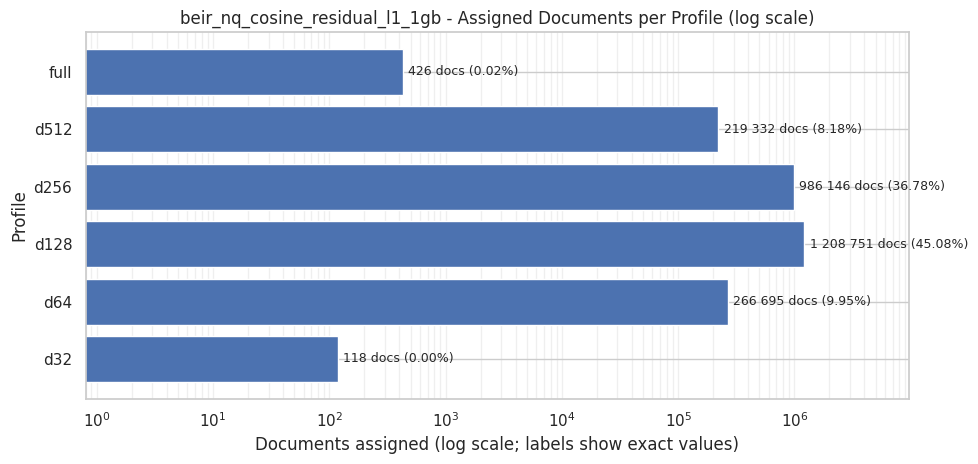

,profile,documents,total_cost_bytes,avg_cost_bytes
0,d128,1208751,309440256.0,256.0
1,d256,986146,504906752.0,512.0
2,d64,266695,34136960.0,128.0
3,d512,219332,224595968.0,1024.0
4,full,426,654336.0,1536.0
5,d32,118,7552.0,64.0


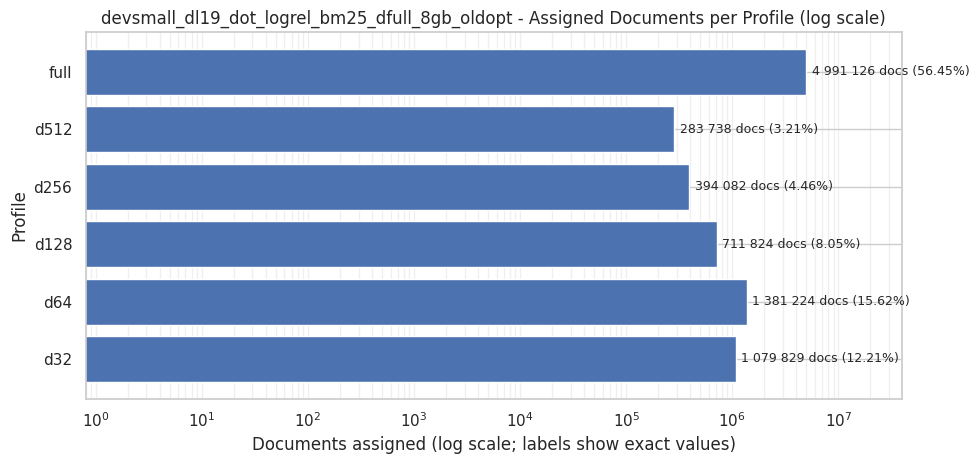

,profile,documents,total_cost_bytes,avg_cost_bytes
0,full,4991126,7.666370e+09,1536.0
1,d64,1381224,1.767967e+08,128.0
2,d32,1079829,6.910906e+07,64.0
3,d128,711824,1.822269e+08,256.0
4,d256,394082,2.017700e+08,512.0
5,d512,283738,2.905477e+08,1024.0


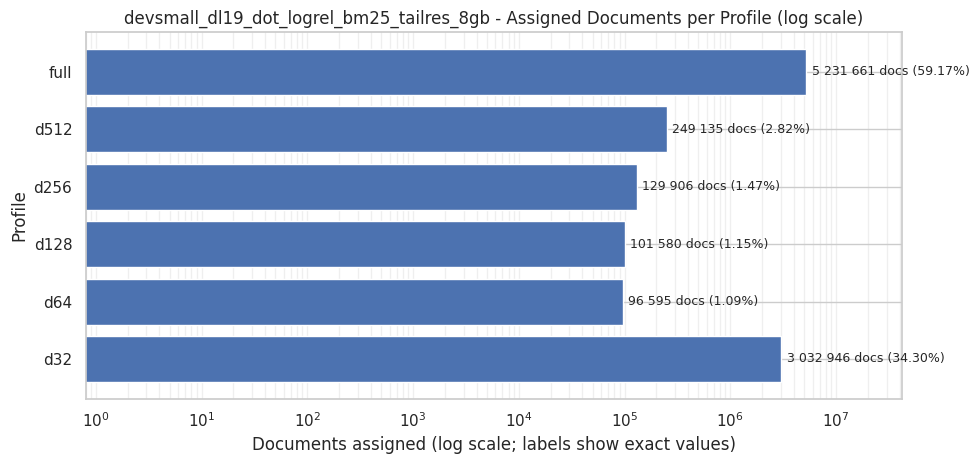

,profile,documents,total_cost_bytes,avg_cost_bytes
0,full,5231661,8.035831e+09,1536.0
1,d32,3032946,1.941085e+08,64.0
2,d512,249135,2.551142e+08,1024.0
3,d256,129906,6.651187e+07,512.0
4,d128,101580,2.600448e+07,256.0
5,d64,96595,1.236416e+07,128.0


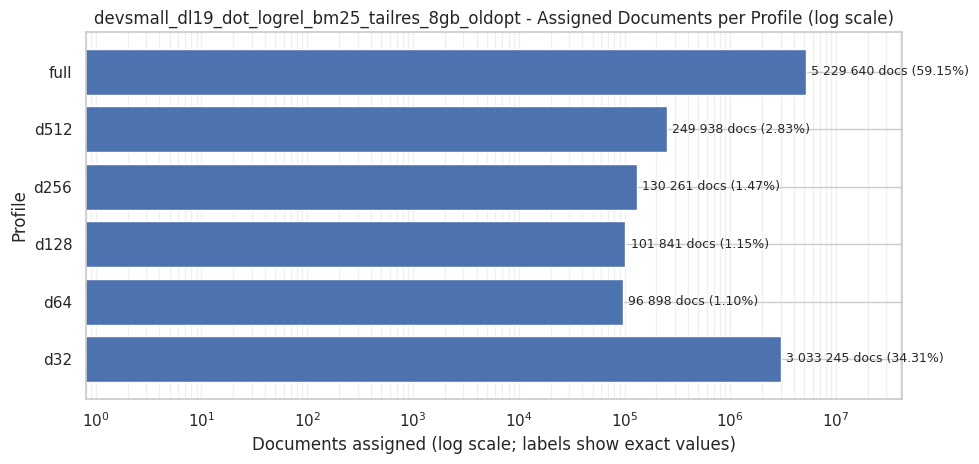

,profile,documents,total_cost_bytes,avg_cost_bytes
0,full,5229640,8.032727e+09,1536.0
1,d32,3033245,1.941277e+08,64.0
2,d512,249938,2.559365e+08,1024.0
3,d256,130261,6.669363e+07,512.0
4,d128,101841,2.607130e+07,256.0
5,d64,96898,1.240294e+07,128.0


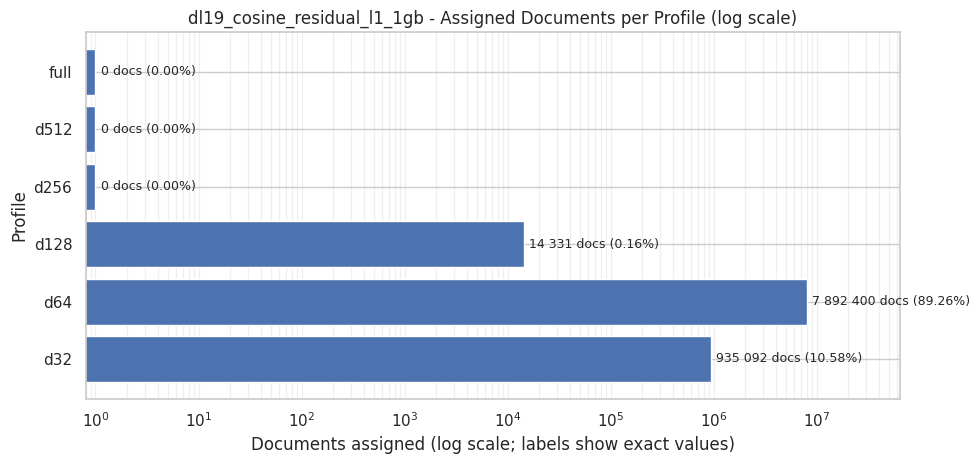

,profile,documents,total_cost_bytes,avg_cost_bytes
0,d64,7892400,1.010227e+09,128.0
1,d32,935092,5.984589e+07,64.0
2,d128,14331,3.668736e+06,256.0


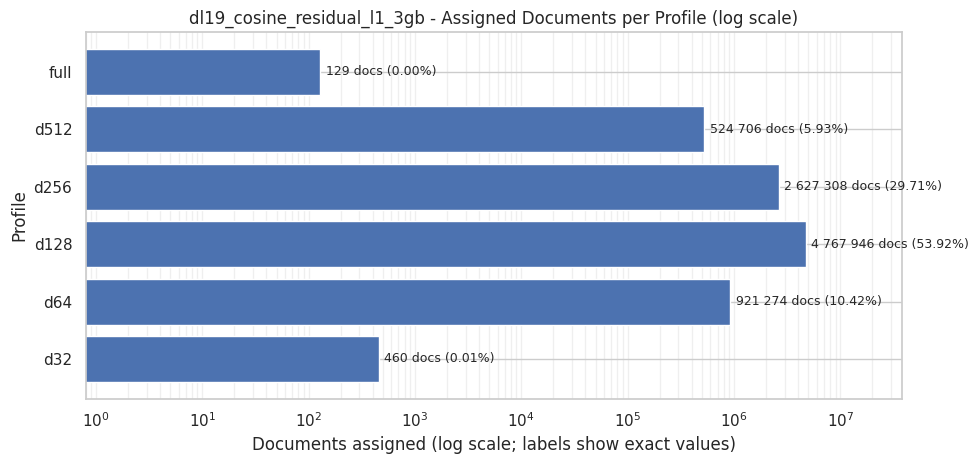

,profile,documents,total_cost_bytes,avg_cost_bytes
0,d128,4767946,1.220594e+09,256.0
1,d256,2627308,1.345182e+09,512.0
2,d64,921274,1.179231e+08,128.0
3,d512,524706,5.372989e+08,1024.0
4,d32,460,2.944000e+04,64.0
5,full,129,1.981440e+05,1536.0


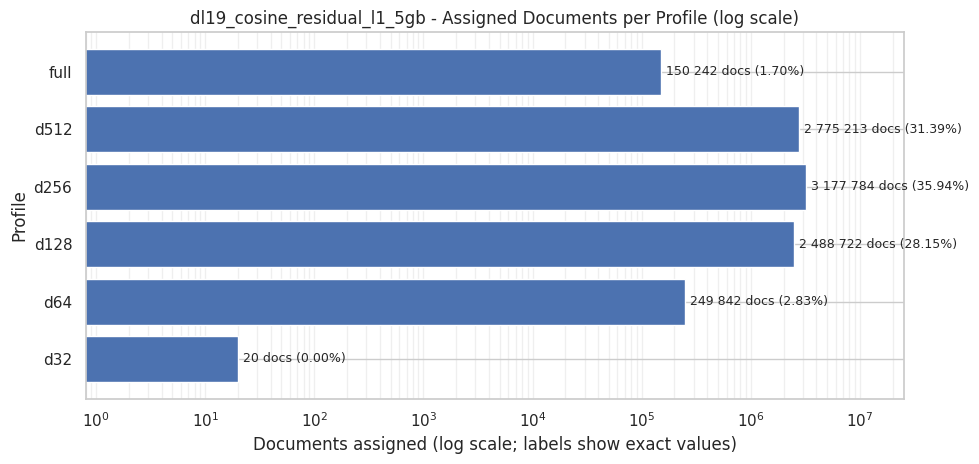

,profile,documents,total_cost_bytes,avg_cost_bytes
0,d256,3177784,1.627025e+09,512.0
1,d512,2775213,2.841818e+09,1024.0
2,d128,2488722,6.371128e+08,256.0
3,d64,249842,3.197978e+07,128.0
4,full,150242,2.307717e+08,1536.0
5,d32,20,1.280000e+03,64.0


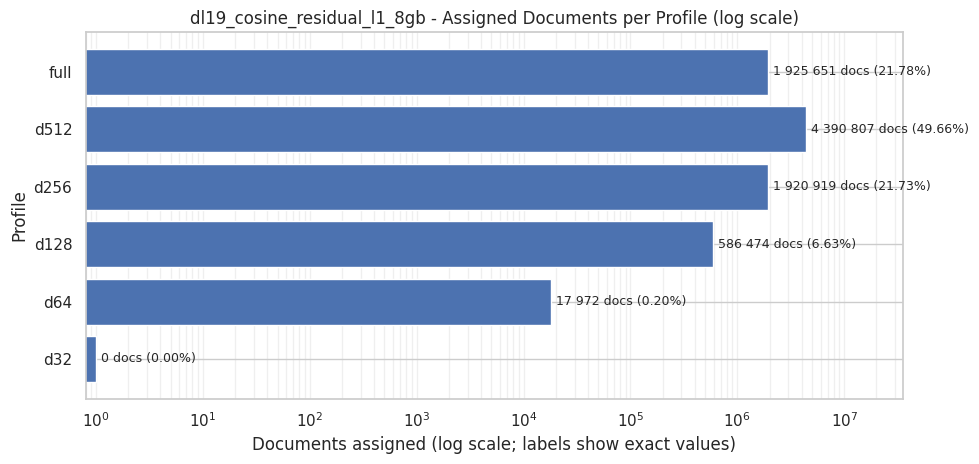

,profile,documents,total_cost_bytes,avg_cost_bytes
0,d512,4390807,4.496186e+09,1024.0
1,full,1925651,2.957800e+09,1536.0
2,d256,1920919,9.835105e+08,512.0
3,d128,586474,1.501373e+08,256.0
4,d64,17972,2.300416e+06,128.0


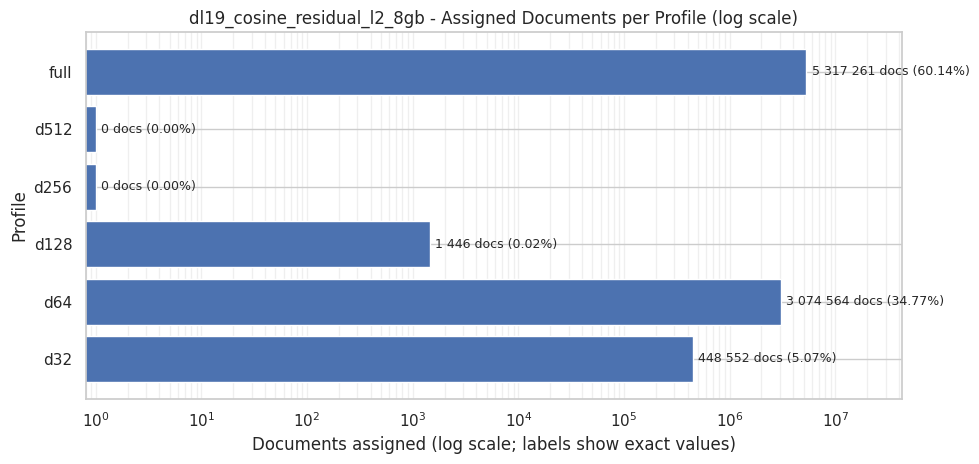

,profile,documents,total_cost_bytes,avg_cost_bytes
0,full,5317261,8.167313e+09,1536.0
1,d64,3074564,3.935442e+08,128.0
2,d32,448552,2.870733e+07,64.0
3,d128,1446,3.701760e+05,256.0


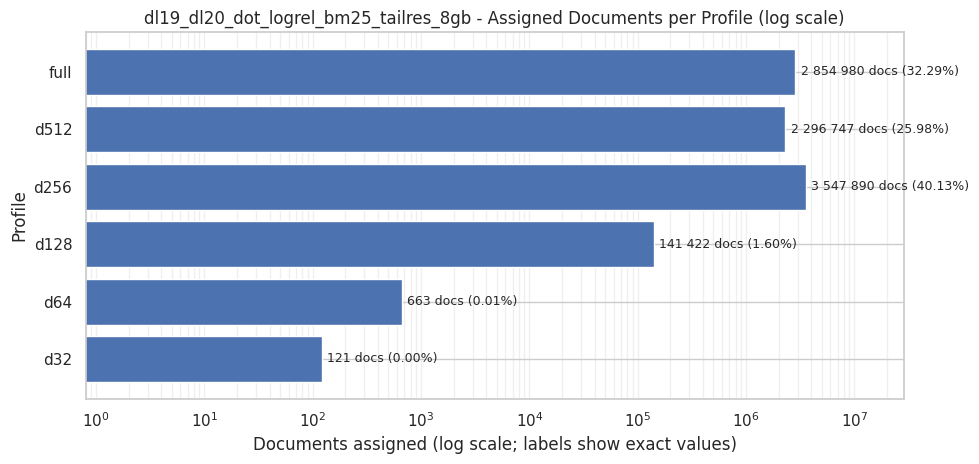

,profile,documents,total_cost_bytes,avg_cost_bytes
0,d256,3547890,1.816520e+09,512.0
1,full,2854980,4.385249e+09,1536.0
2,d512,2296747,2.351869e+09,1024.0
3,d128,141422,3.620403e+07,256.0
4,d64,663,8.486400e+04,128.0
5,d32,121,7.744000e+03,64.0


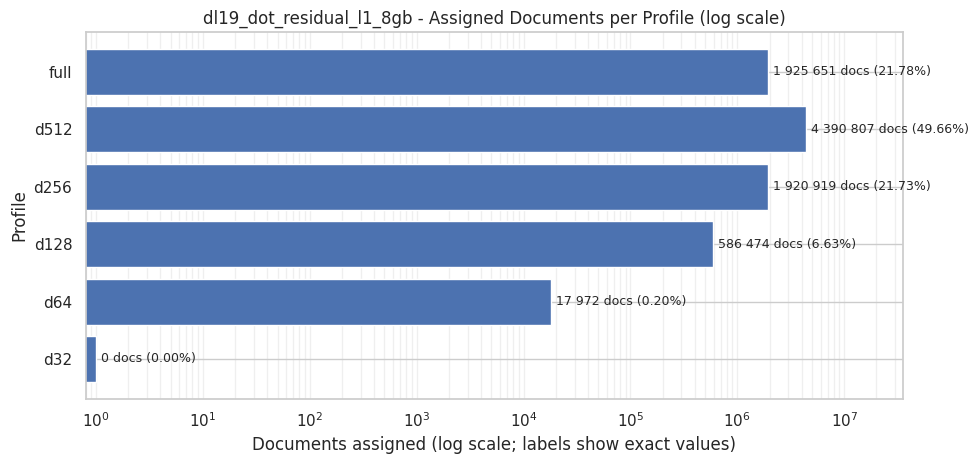

,profile,documents,total_cost_bytes,avg_cost_bytes
0,d512,4390807,4.496186e+09,1024.0
1,full,1925651,2.957800e+09,1536.0
2,d256,1920919,9.835105e+08,512.0
3,d128,586474,1.501373e+08,256.0
4,d64,17972,2.300416e+06,128.0


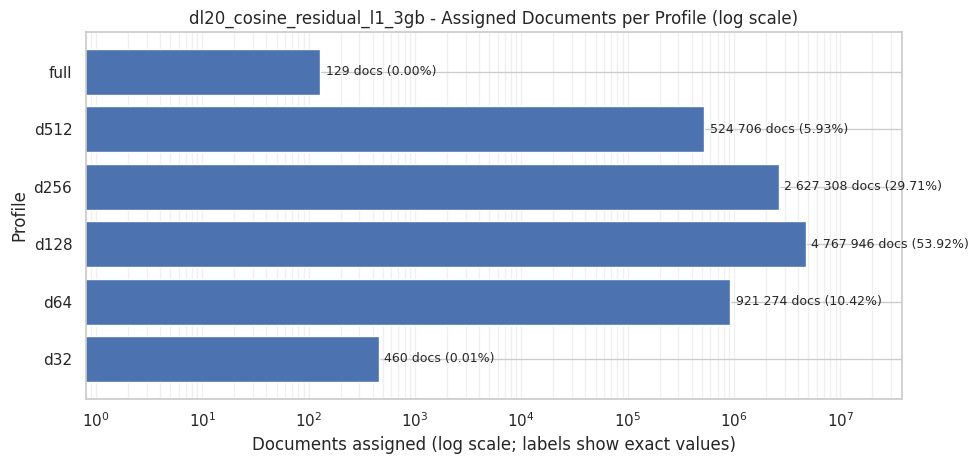

,profile,documents,total_cost_bytes,avg_cost_bytes
0,d128,4767946,1.220594e+09,256.0
1,d256,2627308,1.345182e+09,512.0
2,d64,921274,1.179231e+08,128.0
3,d512,524706,5.372989e+08,1024.0
4,d32,460,2.944000e+04,64.0
5,full,129,1.981440e+05,1536.0


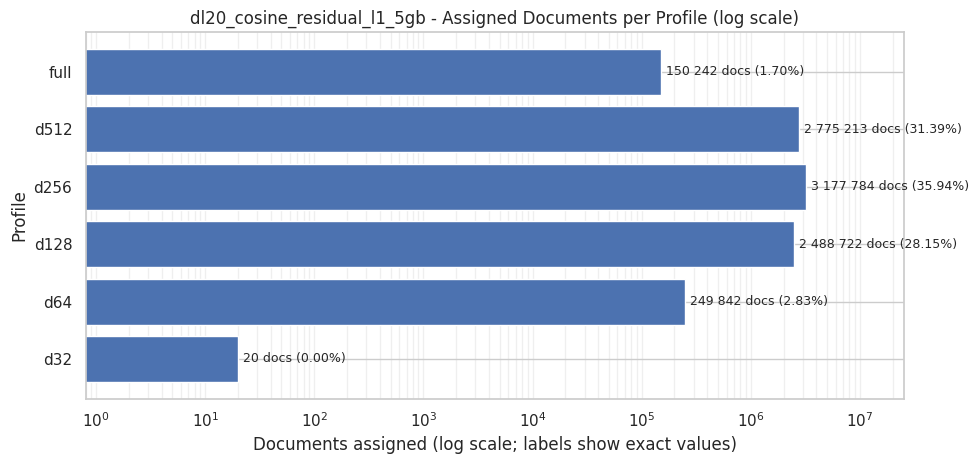

,profile,documents,total_cost_bytes,avg_cost_bytes
0,d256,3177784,1.627025e+09,512.0
1,d512,2775213,2.841818e+09,1024.0
2,d128,2488722,6.371128e+08,256.0
3,d64,249842,3.197978e+07,128.0
4,full,150242,2.307717e+08,1536.0
5,d32,20,1.280000e+03,64.0


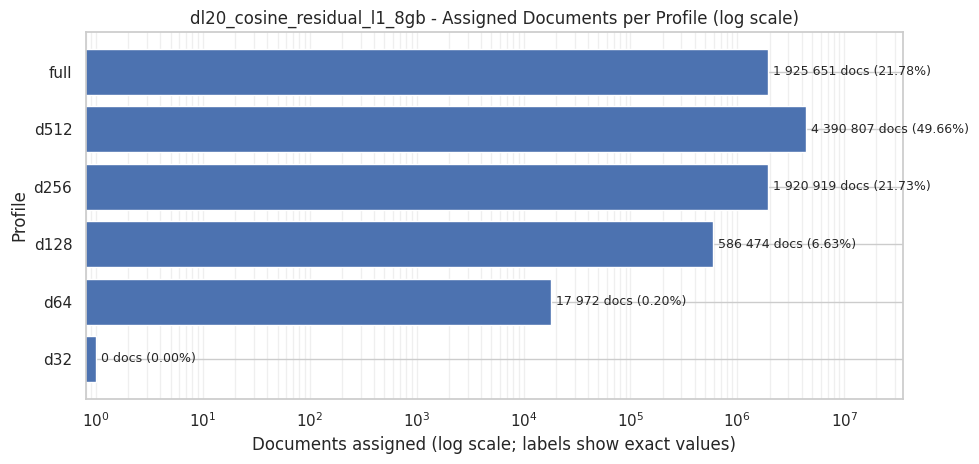

,profile,documents,total_cost_bytes,avg_cost_bytes
0,d512,4390807,4.496186e+09,1024.0
1,full,1925651,2.957800e+09,1536.0
2,d256,1920919,9.835105e+08,512.0
3,d128,586474,1.501373e+08,256.0
4,d64,17972,2.300416e+06,128.0


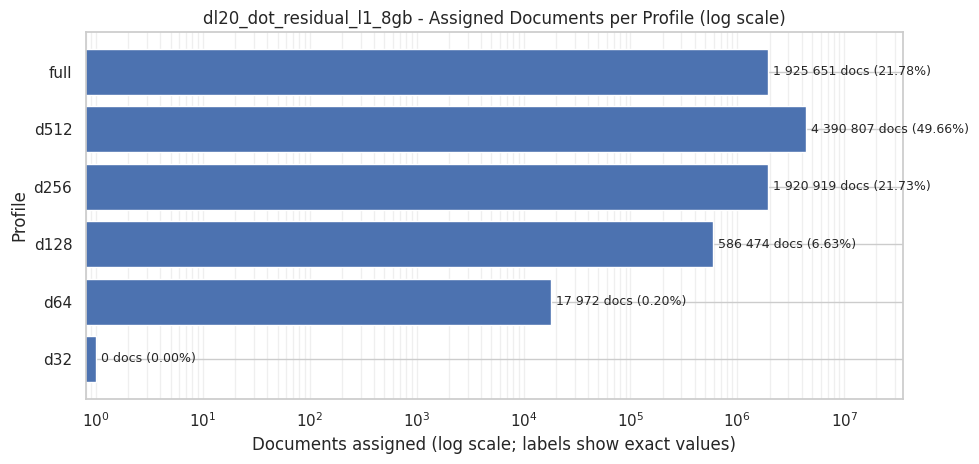

,profile,documents,total_cost_bytes,avg_cost_bytes
0,d512,4390807,4.496186e+09,1024.0
1,full,1925651,2.957800e+09,1536.0
2,d256,1920919,9.835105e+08,512.0
3,d128,586474,1.501373e+08,256.0
4,d64,17972,2.300416e+06,128.0


In [7]:
if not run_bundles:
    print("No bundles available.")
else:
    plotted = 0
    for b in run_bundles:
        counts, cost_summary = _assignment_profile_summary(b)
        if counts.empty:
            continue

        catalog = _load_table(b, "profile_catalog.csv", ["name", "profile", "dimension", "layer", "cost_bytes"])
        if isinstance(catalog, pd.DataFrame) and "name" in catalog.columns:
            profile_order = [str(x) for x in catalog["name"].tolist()]
            counts = counts.reindex(profile_order, fill_value=0)
        else:
            counts = counts.sort_values(ascending=True)

        total_docs = int(counts.sum())
        plot_counts = counts.clip(lower=1)
        fig_height = max(4, 0.55 * len(counts) + 1.5)
        fig, ax = plt.subplots(figsize=(10, fig_height))
        bars = ax.barh(counts.index.astype(str), plot_counts.values)
        ax.set_xscale("log")
        ax.set_title(f"{b['run_name']} - Assigned Documents per Profile (log scale)")
        ax.set_xlabel("Documents assigned (log scale; labels show exact values)")
        ax.set_ylabel("Profile")
        ax.grid(axis="x", which="both", alpha=0.3)

        x_max = max(float(plot_counts.max()), 1.0)
        ax.set_xlim(0.8, x_max * 8.0)
        for bar, count in zip(bars, counts.values):
            pct = (100.0 * count / total_docs) if total_docs else 0.0
            label = f"{_format_count(count)} docs ({pct:.2f}%)"
            ax.text(max(float(count), 1.0) * 1.12, bar.get_y() + bar.get_height() / 2, label, va="center", ha="left", fontsize=9)

        plt.tight_layout()
        _show_and_close(fig)
        plotted += 1

        if not cost_summary.empty:
            display(cost_summary.sort_values("documents", ascending=False).reset_index(drop=True))

        del counts, cost_summary, plot_counts
        if catalog is not None:
            del catalog
        gc.collect()

    if plotted == 0:
        print("No plottable assignments tables found.")


## Utility Comparison (`per_document_utility.parquet`)

Fast comparison plot: one line per profile, with `x` as document index and `y` as utility.

In [8]:
if not run_bundles:
    print("No bundles available.")
else:
    plotted = 0
    max_points_per_profile = 10000

    for b in run_bundles:
        plot_data, utility_col, profile_col = _load_utility_plot_data(b, max_points_per_profile)
        if plot_data.empty or utility_col is None:
            continue

        fig, ax = plt.subplots(figsize=(11, 5))
        if profile_col is None:
            ax.plot(plot_data.index.values, plot_data[utility_col].values, linewidth=1.0, label="utility")
        else:
            for profile_name, group in plot_data.groupby(profile_col, sort=True):
                group = group.reset_index(drop=True)
                ax.plot(group.index.values, group[utility_col].values, linewidth=1.0, label=str(profile_name))

        ax.set_title(f"{b['run_name']} - Utility by Document (One Line per Profile)")
        ax.set_xlabel("Document index")
        ax.set_ylabel(utility_col)
        ax.legend(title="Profile", loc="best", fontsize=8)
        plt.tight_layout()
        _show_and_close(fig)
        plotted += 1

        del plot_data
        gc.collect()

    if plotted == 0:
        print("No plottable per_document_utility tables found.")


KeyboardInterrupt: 

## Evaluation Comparison (`pt_experiment.csv`, `metrics_wide.csv`)

Plots only retrieval metric columns from evaluation artifacts. Statistical-test columns such as p-values, significance flags, confidence intervals, and plus/minus columns are filtered out.

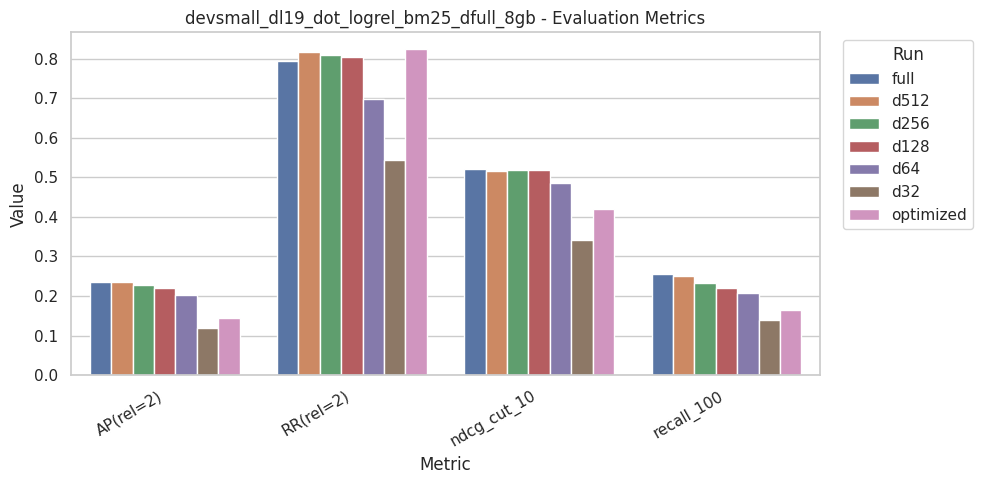

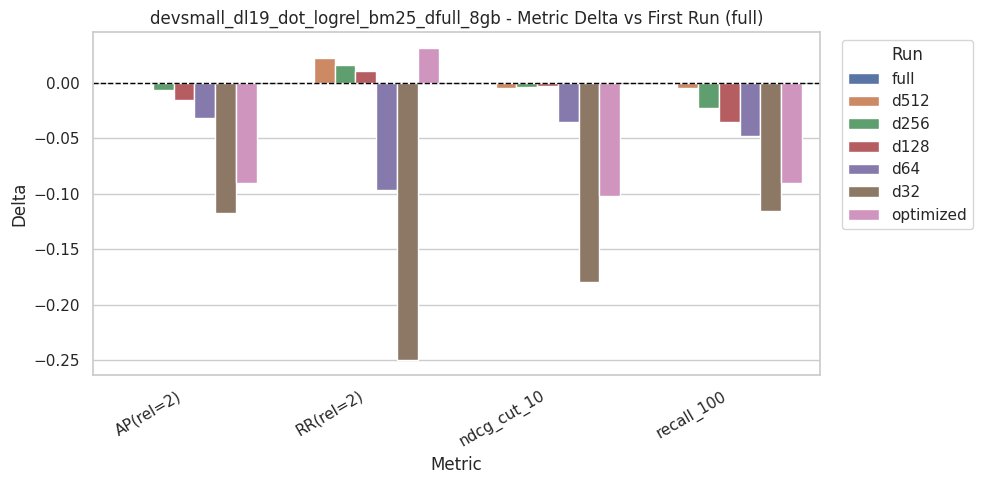

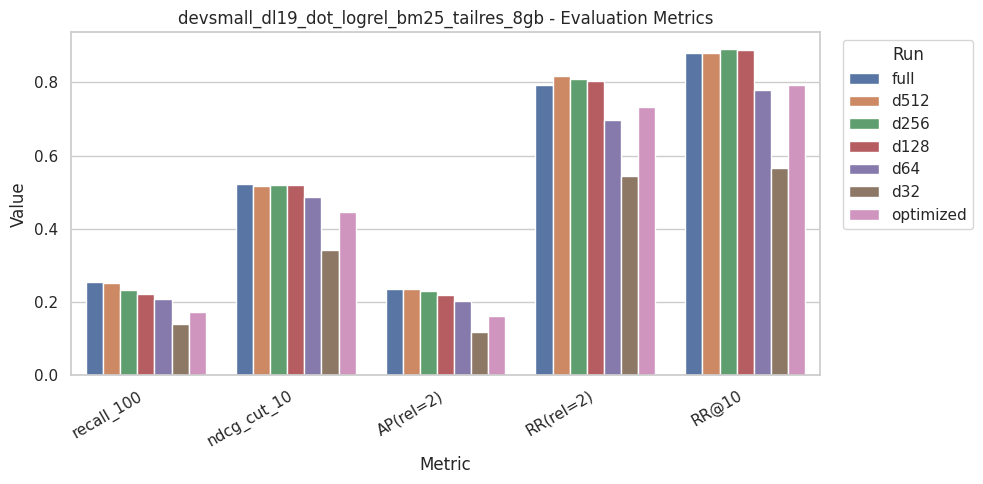

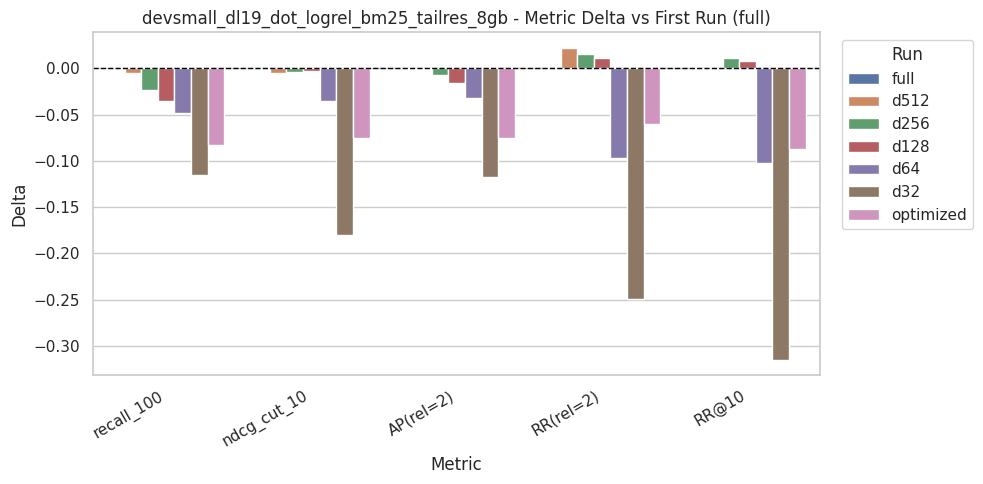

In [ ]:
if not run_bundles:
    print("No bundles available.")
else:
    plotted = 0
    for b in run_bundles:
        df = _load_table(b, "pt_experiment.csv")
        run_col = None

        if df is not None and not df.empty:
            run_col = _first_existing_col(df, ["name", "system", "run", "model"])
        else:
            wide_df = _load_table(b, "metrics_wide.csv")
            if wide_df is not None and not wide_df.empty:
                df = wide_df.copy()
                if "model_id" in df.columns and "dimension" in df.columns:
                    df["__run_label"] = df["model_id"].astype(str) + "_d" + df["dimension"].astype(str)
                    run_col = "__run_label"
                else:
                    run_col = _first_existing_col(df, ["model_id", "name", "system", "run", "model"])
            else:
                continue

        metric_cols = _evaluation_metric_cols(df)
        if not run_col or not metric_cols:
            print(f"{b['run_name']}: no metric columns found after filtering statistical-test columns.")
            continue

        plot_df = df[[run_col] + metric_cols].copy()
        plot_df[run_col] = plot_df[run_col].astype(str).map(_short_run_label)
        melted = plot_df.melt(id_vars=[run_col], value_vars=metric_cols, var_name="metric", value_name="value")

        fig_width = max(10, 1.4 * len(metric_cols))
        fig, ax = plt.subplots(figsize=(fig_width, 5))
        if sns is not None:
            sns.barplot(data=melted, x="metric", y="value", hue=run_col, ax=ax)
        else:
            for label, grp in melted.groupby(run_col):
                ax.plot(grp["metric"], grp["value"], marker="o", label=label)
            ax.legend()
        ax.set_title(f"{b['run_name']} - Evaluation Metrics")
        ax.set_xlabel("Metric")
        ax.set_ylabel("Value")
        plt.xticks(rotation=30, ha="right")
        ax.legend(title="Run", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        _show_and_close(fig)
        plotted += 1

        baseline = df.iloc[0]
        baseline_name = _short_run_label(str(baseline[run_col]))
        delta_rows = []
        for _, row in df.iterrows():
            current_name = _short_run_label(str(row[run_col]))
            for m in metric_cols:
                delta_rows.append(
                    {
                        "run_name": current_name,
                        "metric": m,
                        "delta_vs_first_run": float(row[m] - baseline[m]),
                    }
                )

        delta_df = pd.DataFrame(delta_rows)
        if not delta_df.empty:
            fig, ax = plt.subplots(figsize=(fig_width, 5))
            if sns is not None:
                sns.barplot(data=delta_df, x="metric", y="delta_vs_first_run", hue="run_name", ax=ax)
            else:
                for name, grp in delta_df.groupby("run_name"):
                    ax.plot(grp["metric"], grp["delta_vs_first_run"], marker="o", label=name)
                ax.legend()
            ax.axhline(0.0, color="black", linewidth=1, linestyle="--")
            ax.set_title(f"{b['run_name']} - Metric Delta vs First Run ({baseline_name})")
            ax.set_xlabel("Metric")
            ax.set_ylabel("Delta")
            plt.xticks(rotation=30, ha="right")
            ax.legend(title="Run", bbox_to_anchor=(1.02, 1), loc="upper left")
            plt.tight_layout()
            _show_and_close(fig)
            plotted += 1

        gc.collect()

    if plotted == 0:
        print("No plottable evaluation tables found (`pt_experiment.csv` or `metrics_wide.csv`).")

## Summary and Memory Comparison (`summary.json`, `memory_summary.json`)

Displays compact KPI tables and memory usage bars per run using summary JSON artifacts.

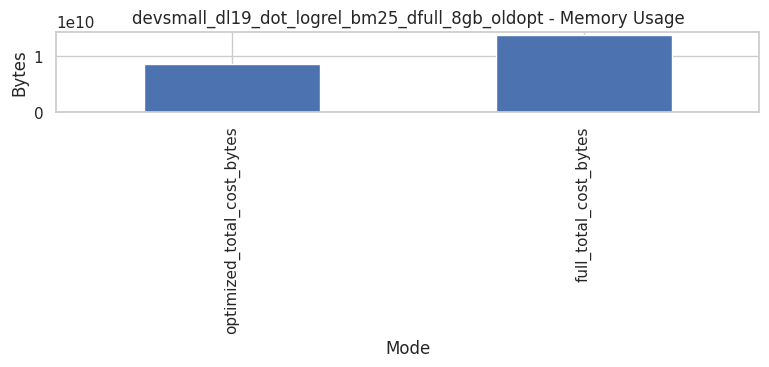

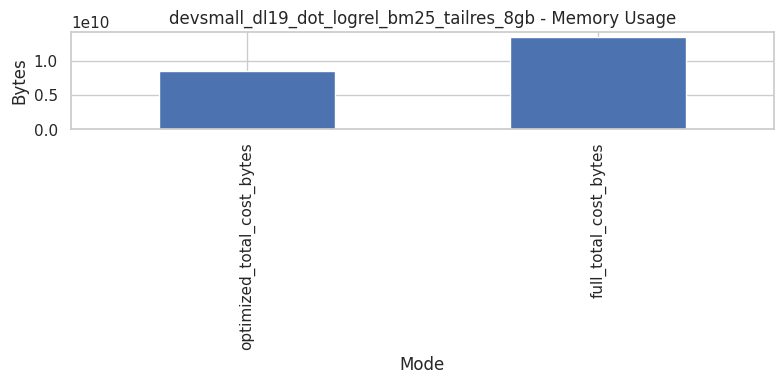

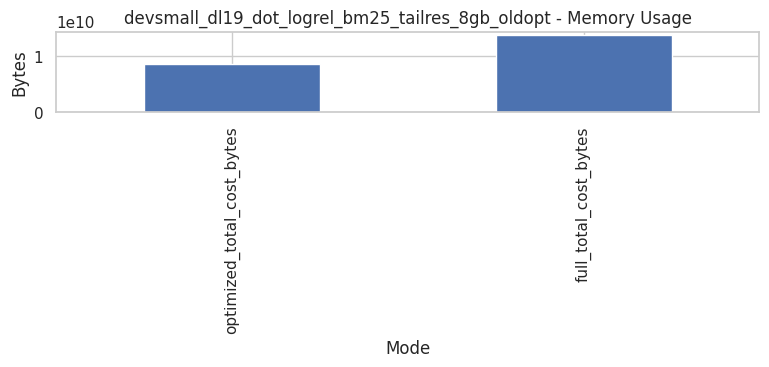

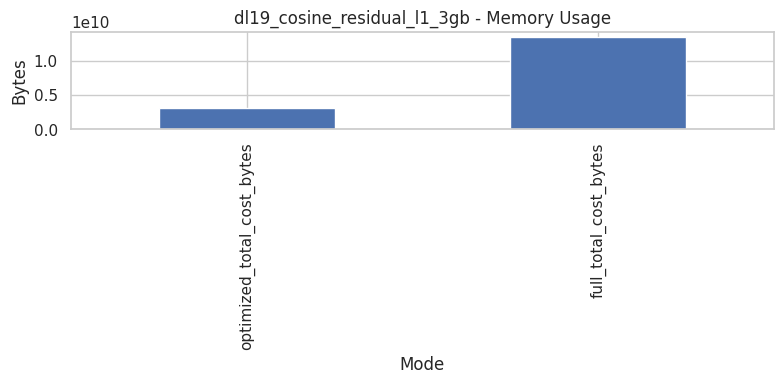

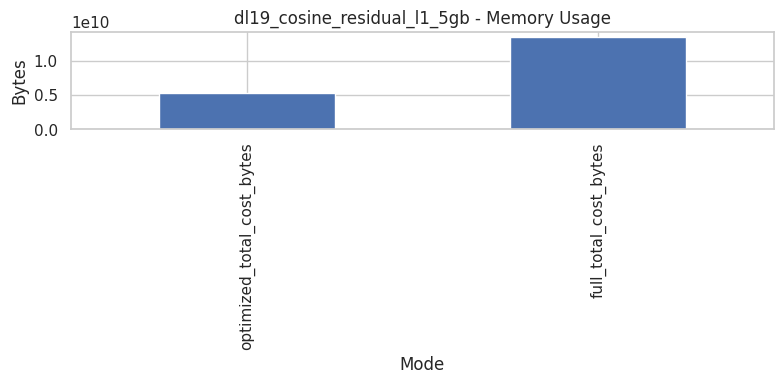

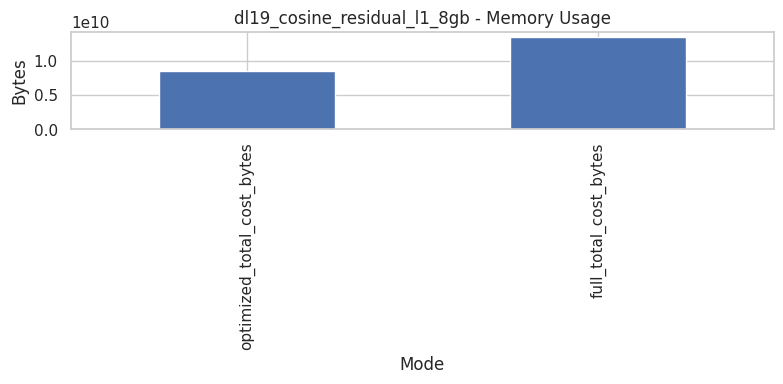

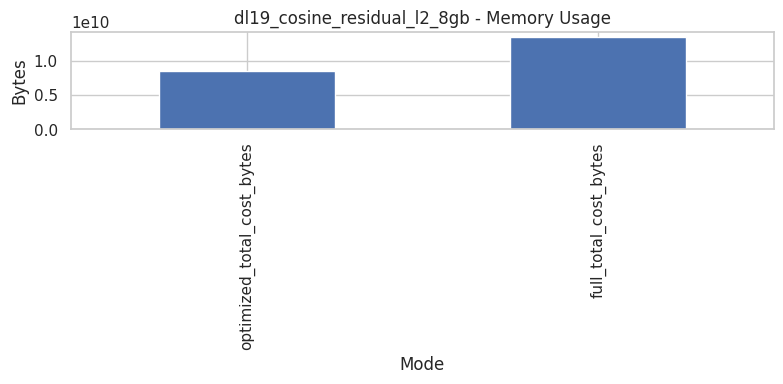

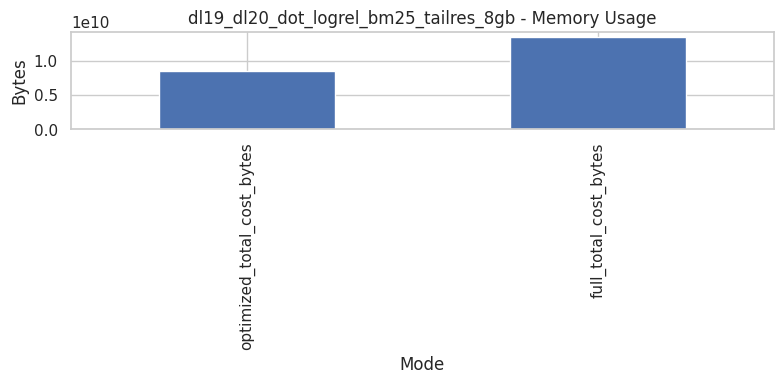

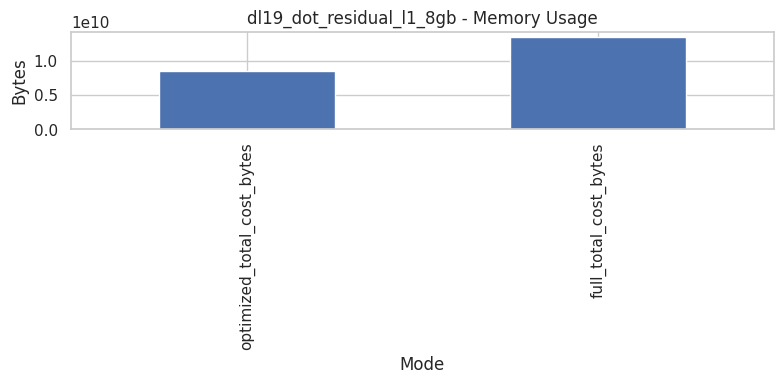

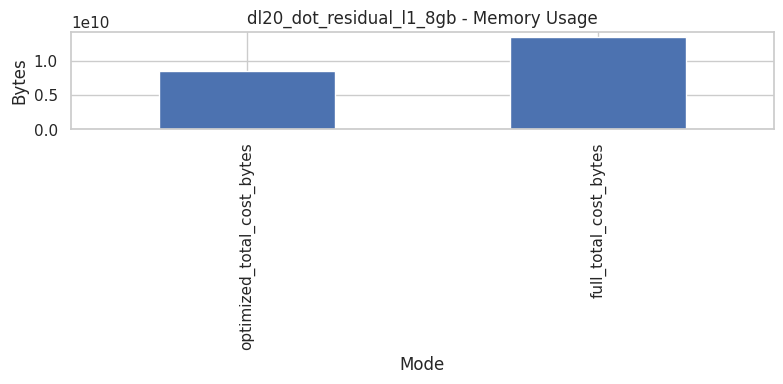

,run_name,lambda_star,optimized_total_utility,num_docs,num_queries,budget_bytes,optimized_total_cost_bytes,full_total_cost_bytes
0,devsmall_dl19_dot_logrel_bm25_dfull_8gb_oldopt,1.034131e-04,4.142972e+06,8841823,6980,8589934592,8586819904,13581040128
1,devsmall_dl19_dot_logrel_bm25_tailres_8gb,2.493485e-05,1.467409e+06,8841823,6980,8589934592,8589934592,13581040128
2,devsmall_dl19_dot_logrel_bm25_tailres_8gb_oldopt,2.491093e-05,1.467360e+06,8841823,6980,8589934592,8587959104,13581040128
3,dl19_cosine_residual_l1_3gb,6.247042e-04,2.709678e+06,8841823,0,3221225472,3221225472,13581040128
4,dl19_cosine_residual_l1_5gb,6.068531e-04,4.029600e+06,8841823,0,5368709120,5368709120,13581040128
5,dl19_cosine_residual_l1_8gb,5.926630e-04,5.960126e+06,8841823,0,8589934592,8589934592,13581040128
6,dl19_cosine_residual_l2_8gb,6.101373e-04,5.836649e+06,8841823,0,8589934592,8589934592,13581040128
7,dl19_dl20_dot_logrel_bm25_tailres_8gb,7.169422e-13,3.041670e+05,8841823,200,8589934592,8589934528,13581040128
8,dl19_dot_residual_l1_8gb,5.926630e-04,5.960126e+06,8841823,0,8589934592,8589934592,13581040128
9,dl20_dot_residual_l1_8gb,5.926630e-04,5.960126e+06,8841823,0,8589934592,8589934592,13581040128


In [ ]:
if not run_bundles:
    print("No bundles available.")
else:
    plotted = 0
    kpi_rows = []
    for b in run_bundles:
        summary = b["json"].get("summary.json", {})
        memory = b["json"].get("memory_summary.json", {})
        if not summary and not memory:
            continue

        row = {
            "run_name": b["run_name"],
            "lambda_star": summary.get("lambda_star"),
            "optimized_total_utility": summary.get("optimized_total_utility"),
            "num_docs": summary.get("num_docs"),
            "num_queries": summary.get("num_queries"),
            "budget_bytes": memory.get("budget_bytes"),
            "optimized_total_cost_bytes": memory.get("optimized_total_cost_bytes"),
            "full_total_cost_bytes": memory.get("full_total_cost_bytes"),
        }
        kpi_rows.append(row)

        if memory.get("optimized_total_cost_bytes") is not None and memory.get("full_total_cost_bytes") is not None:
            s = pd.Series({
                "optimized_total_cost_bytes": memory["optimized_total_cost_bytes"],
                "full_total_cost_bytes": memory["full_total_cost_bytes"],
            })
            fig, ax = plt.subplots(figsize=(8, 4))
            s.plot(kind="bar", ax=ax)
            ax.set_title(f"{b['run_name']} - Memory Usage")
            ax.set_xlabel("Mode")
            ax.set_ylabel("Bytes")
            plt.tight_layout()
            _show_and_close(fig)
            plotted += 1

    if kpi_rows:
        display(pd.DataFrame(kpi_rows).sort_values("run_name").reset_index(drop=True))
    if plotted == 0 and not kpi_rows:
        print("No summary/memory JSON data found.")

## Retrieval Runs Comparison (`full_run.parquet`, `optimized_run.parquet`)

Compares score distributions and per-query top-k overlap between full and optimized runs for each experiment.

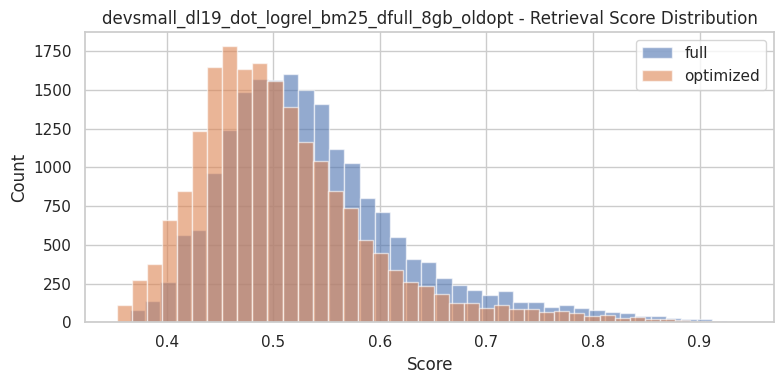

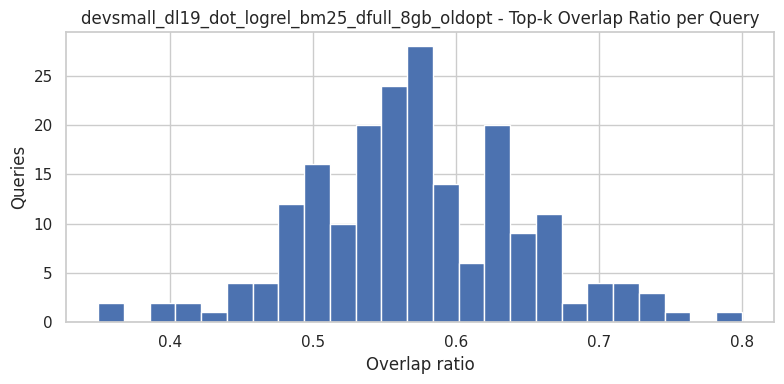

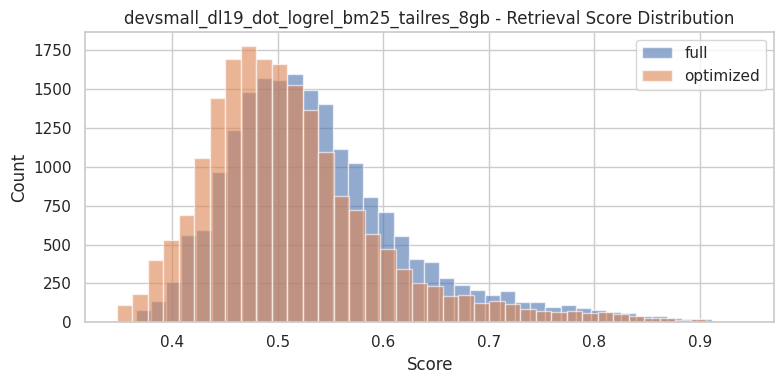

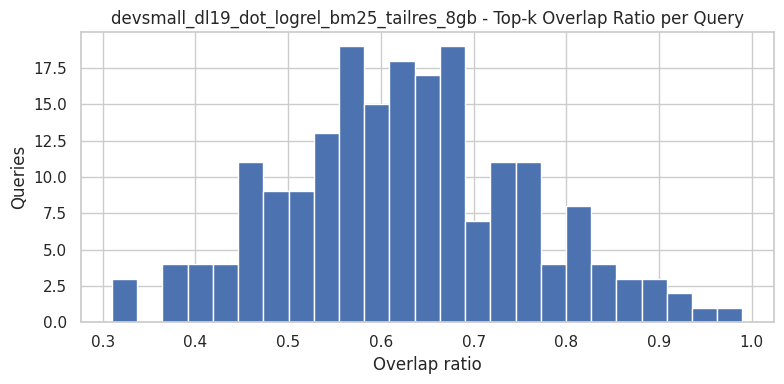

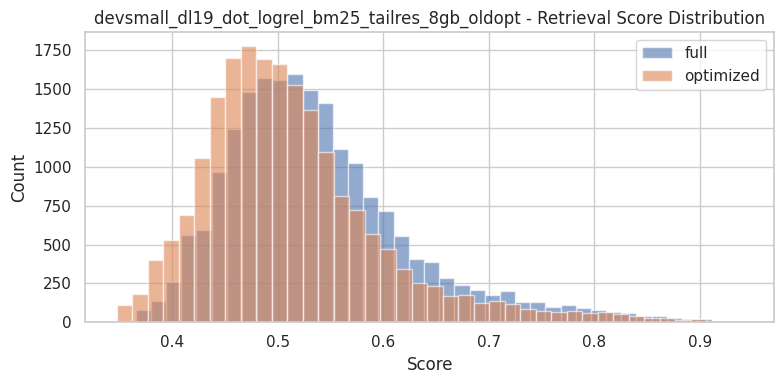

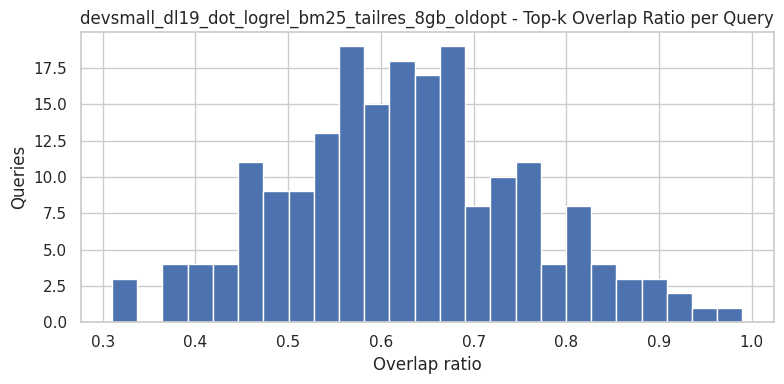

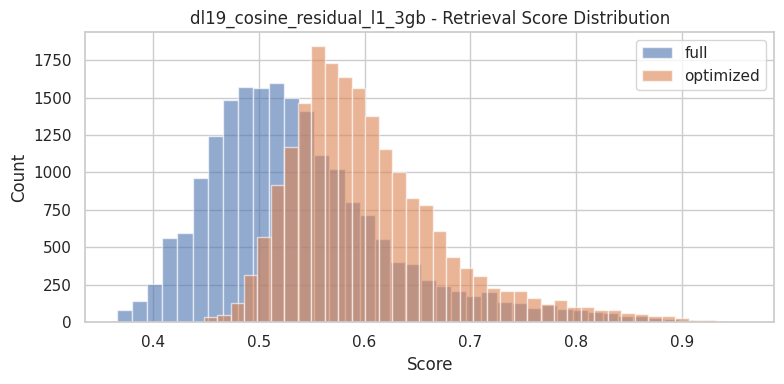

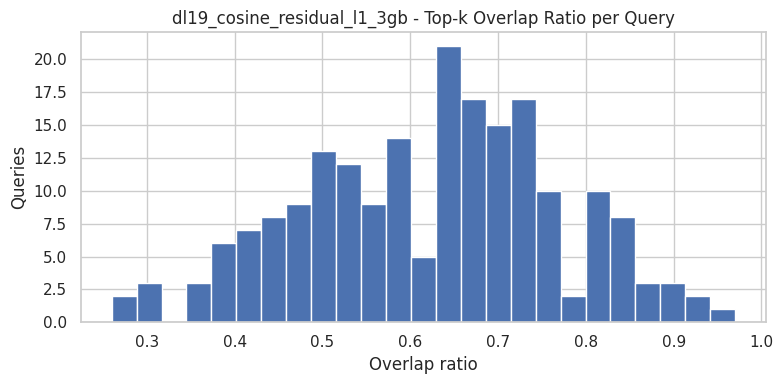

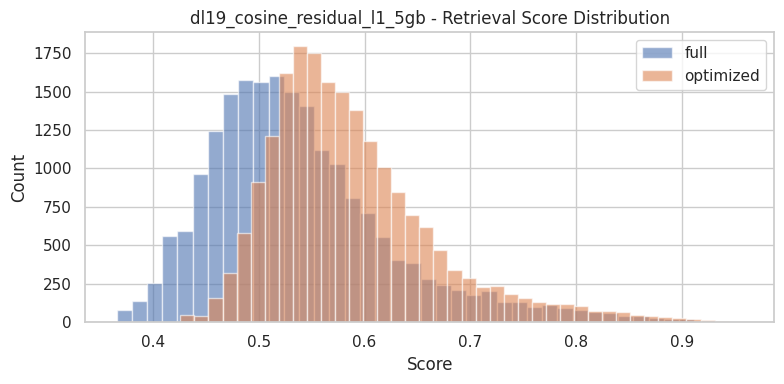

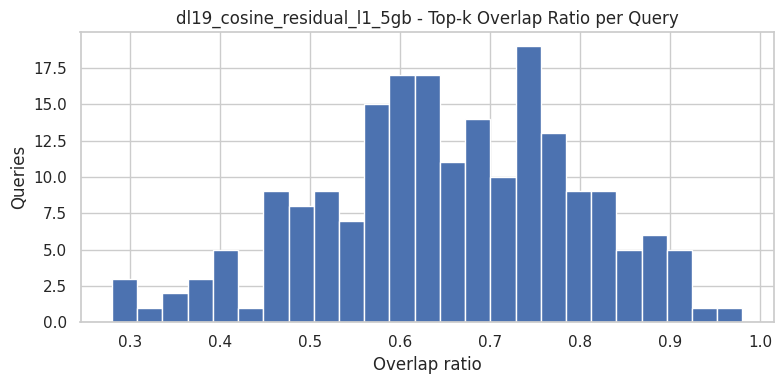

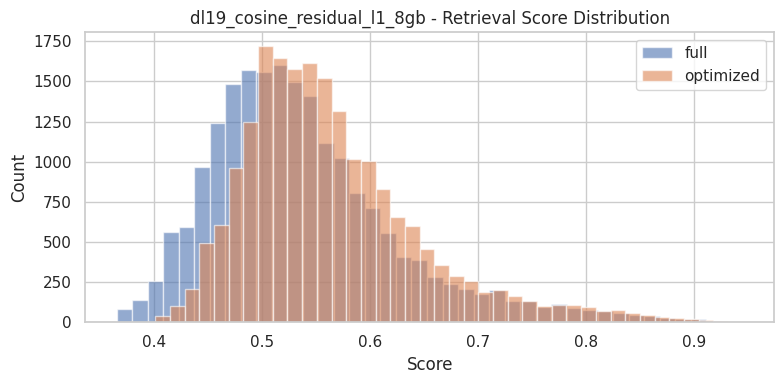

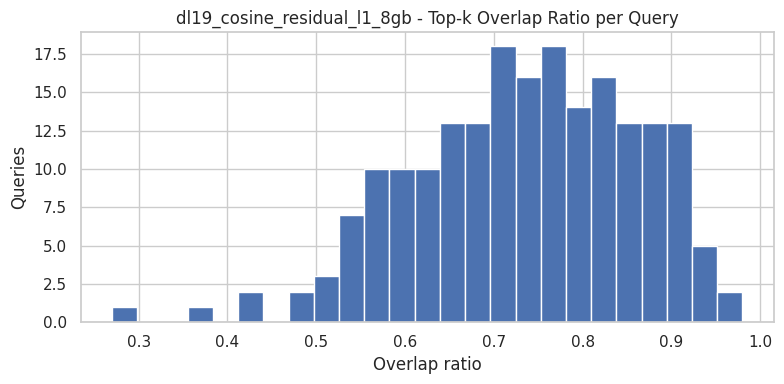

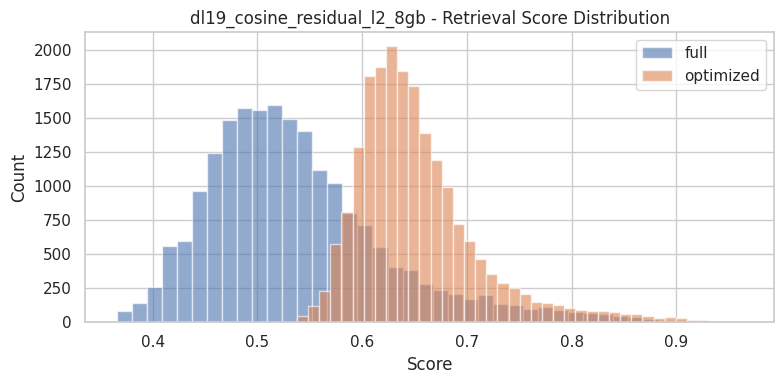

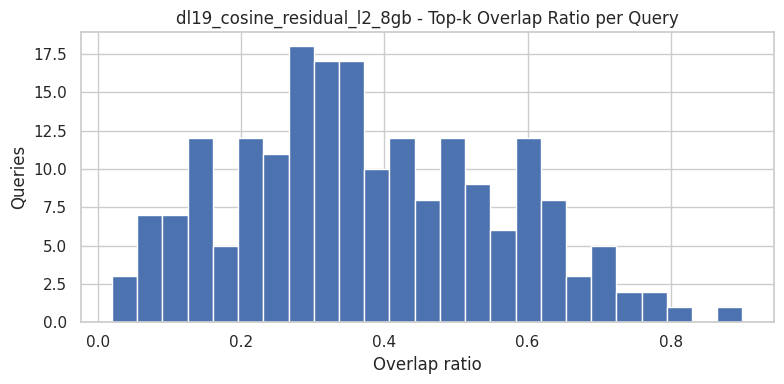

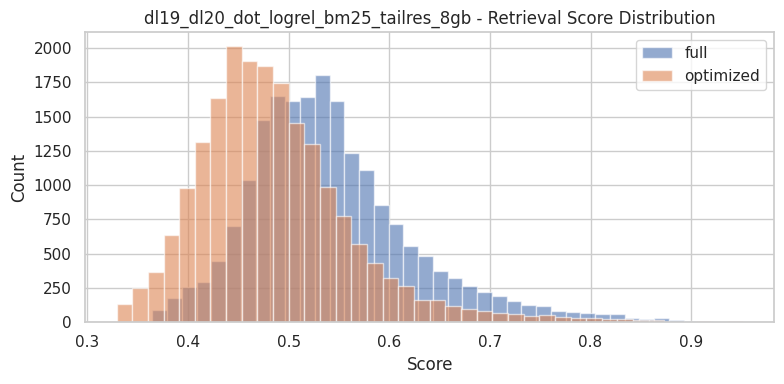

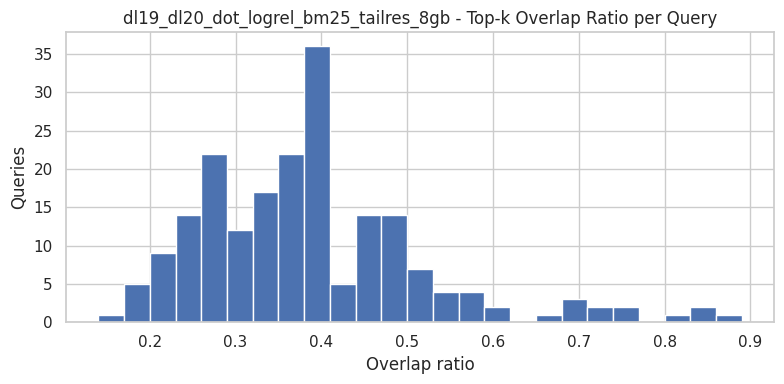

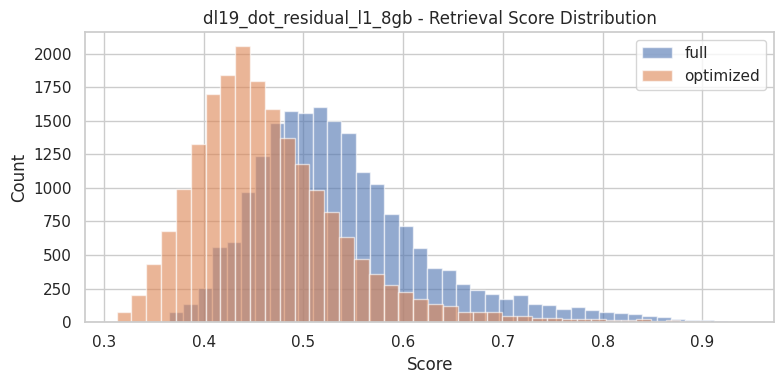

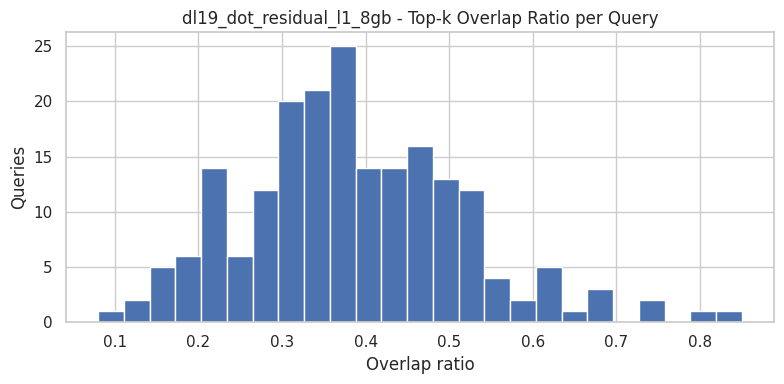

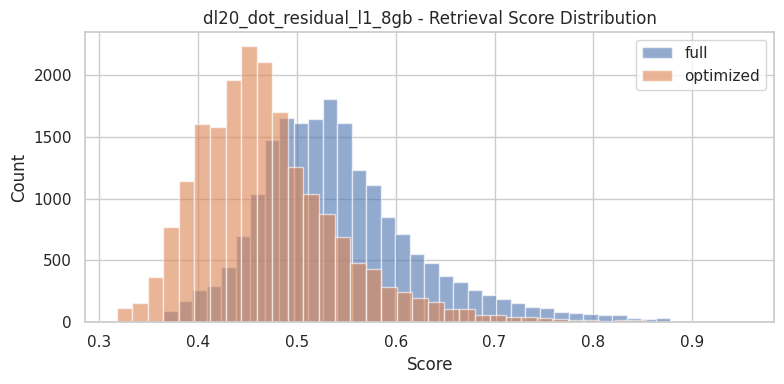

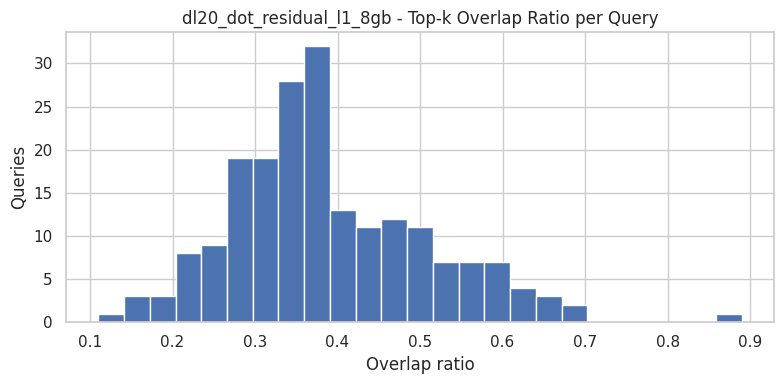

In [ ]:
if not run_bundles:
    print("No bundles available.")
else:
    plotted = 0
    for b in run_bundles:
        full_df = _load_table(b, "full_run.parquet", ["qid", "query_id", "docno", "doc_id", "score", "sim", "similarity"])
        opt_df = _load_table(b, "optimized_run.parquet", ["qid", "query_id", "docno", "doc_id", "score", "sim", "similarity"])
        if full_df is None or opt_df is None or full_df.empty or opt_df.empty:
            continue

        full_score_col = _first_existing_col(full_df, ["score", "sim", "similarity"])
        opt_score_col = _first_existing_col(opt_df, ["score", "sim", "similarity"])

        if full_score_col and opt_score_col:
            fig, ax = plt.subplots(figsize=(8, 4))
            ax.hist(full_df[full_score_col].dropna(), bins=40, alpha=0.6, label="full")
            ax.hist(opt_df[opt_score_col].dropna(), bins=40, alpha=0.6, label="optimized")
            ax.set_title(f"{b['run_name']} - Retrieval Score Distribution")
            ax.set_xlabel("Score")
            ax.set_ylabel("Count")
            ax.legend()
            plt.tight_layout()
            _show_and_close(fig)
            plotted += 1

        qid_col_full = _first_existing_col(full_df, ["qid", "query_id"])
        doc_col_full = _first_existing_col(full_df, ["docno", "doc_id"])
        qid_col_opt = _first_existing_col(opt_df, ["qid", "query_id"])
        doc_col_opt = _first_existing_col(opt_df, ["docno", "doc_id"])

        if qid_col_full and doc_col_full and qid_col_opt and doc_col_opt:
            overlaps = []
            full_groups = full_df.groupby(qid_col_full)[doc_col_full].apply(set)
            opt_groups = opt_df.groupby(qid_col_opt)[doc_col_opt].apply(set)
            common_qids = sorted(set(full_groups.index).intersection(set(opt_groups.index)))
            for qid in common_qids:
                a = full_groups.loc[qid]
                bset = opt_groups.loc[qid]
                denom = max(len(a), 1)
                overlaps.append(len(a.intersection(bset)) / denom)

            if overlaps:
                fig, ax = plt.subplots(figsize=(8, 4))
                ax.hist(overlaps, bins=25)
                ax.set_title(f"{b['run_name']} - Top-k Overlap Ratio per Query")
                ax.set_xlabel("Overlap ratio")
                ax.set_ylabel("Queries")
                plt.tight_layout()
                _show_and_close(fig)
                plotted += 1

        gc.collect()

    if plotted == 0:
        print("No full/optimized run pairs found for plotting.")

## Cross-Run Summary Builder

Builds a single comparison table with core KPIs, memory savings, and evaluation metrics across all runs.

In [ ]:
def build_cross_run_summary(run_bundles: list[dict[str, Any]]) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    for b in run_bundles:
        run_name = b["run_name"]
        summary = b.get("json", {}).get("summary.json", {})
        memory = b.get("json", {}).get("memory_summary.json", {})
        pt_eval = _load_table(b, "pt_experiment.csv")
        wide_eval = _load_table(b, "metrics_wide.csv")

        base_row = {
            "experiment_run_name": run_name,
            "lambda_star": summary.get("lambda_star"),
            "optimized_total_utility": summary.get("optimized_total_utility"),
            "num_docs": summary.get("num_docs"),
            "num_queries": summary.get("num_queries"),
            "num_eval_queries": summary.get("num_eval_queries"),
            "budget_bytes": memory.get("budget_bytes"),
            "optimized_total_cost_bytes": memory.get("optimized_total_cost_bytes"),
            "full_total_cost_bytes": memory.get("full_total_cost_bytes"),
        }
        if base_row["optimized_total_cost_bytes"] is not None and base_row["full_total_cost_bytes"] is not None and base_row["full_total_cost_bytes"]:
            base_row["memory_saved_pct"] = 100.0 * (1.0 - (base_row["optimized_total_cost_bytes"] / base_row["full_total_cost_bytes"]))
        else:
            base_row["memory_saved_pct"] = np.nan

        eval_df = None
        run_col = None
        if isinstance(pt_eval, pd.DataFrame) and not pt_eval.empty:
            eval_df = pt_eval.copy()
            run_col = _first_existing_col(eval_df, ["name", "run", "system", "model"])
        elif isinstance(wide_eval, pd.DataFrame) and not wide_eval.empty:
            eval_df = wide_eval.copy()
            if "model_id" in eval_df.columns and "dimension" in eval_df.columns:
                eval_df["__run_label"] = eval_df["model_id"].astype(str) + "_d" + eval_df["dimension"].astype(str)
                run_col = "__run_label"
            else:
                run_col = _first_existing_col(eval_df, ["model_id", "name", "run", "system", "model"])

        if isinstance(eval_df, pd.DataFrame) and not eval_df.empty:
            metric_cols = _evaluation_metric_cols(eval_df)

            if run_col and metric_cols:
                baseline = eval_df.iloc[0]
                baseline_name = _short_run_label(str(baseline[run_col]))

                for _, row in eval_df.iterrows():
                    out = dict(base_row)
                    current_name = _short_run_label(str(row[run_col]))
                    out["eval_run_name"] = current_name
                    out["eval_baseline_name"] = baseline_name
                    out["is_baseline"] = current_name == baseline_name

                    for m in metric_cols:
                        out[f"metric__{m}"] = float(row[m])
                        out[f"metric_delta_vs_baseline__{m}"] = float(row[m] - baseline[m])

                    rows.append(out)
            else:
                rows.append(base_row)
        else:
            rows.append(base_row)

    if not rows:
        return pd.DataFrame()

    df = pd.DataFrame(rows)
    sort_cols = [c for c in ["experiment_run_name", "eval_run_name"] if c in df.columns]
    return df.sort_values(sort_cols, na_position="last").reset_index(drop=True) if sort_cols else df


cross_summary = build_cross_run_summary(run_bundles)
if cross_summary.empty:
    print("No cross-run summary available yet.")
else:
    display(cross_summary)

,experiment_run_name,lambda_star,optimized_total_utility,num_docs,num_queries,num_eval_queries,budget_bytes,optimized_total_cost_bytes,full_total_cost_bytes,memory_saved_pct,eval_run_name,eval_baseline_name,is_baseline,metric__AP(rel=2),metric_delta_vs_baseline__AP(rel=2),metric__RR(rel=2),metric_delta_vs_baseline__RR(rel=2),metric__ndcg_cut_10,metric_delta_vs_baseline__ndcg_cut_10,metric__recall_100,metric_delta_vs_baseline__recall_100,metric__RR@10,metric_delta_vs_baseline__RR@10
0,devsmall_dl19_dot_logrel_bm25_dfull_8gb_oldopt,0.000103,4.142972e+06,8841823,6980,200,8589934592,8586819904,13581040128,36.773474,d128,full,False,0.2199,-0.0158,0.8050,0.0108,0.5193,-0.0030,0.2206,-0.0350,NaN,NaN
1,devsmall_dl19_dot_logrel_bm25_dfull_8gb_oldopt,0.000103,4.142972e+06,8841823,6980,200,8589934592,8586819904,13581040128,36.773474,d256,full,False,0.2288,-0.0069,0.8098,0.0156,0.5187,-0.0036,0.2326,-0.0230,NaN,NaN
2,devsmall_dl19_dot_logrel_bm25_dfull_8gb_oldopt,0.000103,4.142972e+06,8841823,6980,200,8589934592,8586819904,13581040128,36.773474,d32,full,False,0.1180,-0.1177,0.5449,-0.2493,0.3425,-0.1798,0.1400,-0.1156,NaN,NaN
3,devsmall_dl19_dot_logrel_bm25_dfull_8gb_oldopt,0.000103,4.142972e+06,8841823,6980,200,8589934592,8586819904,13581040128,36.773474,d512,full,False,0.2355,-0.0002,0.8163,0.0221,0.5171,-0.0052,0.2509,-0.0047,NaN,NaN
4,devsmall_dl19_dot_logrel_bm25_dfull_8gb_oldopt,0.000103,4.142972e+06,8841823,6980,200,8589934592,8586819904,13581040128,36.773474,d64,full,False,0.2036,-0.0321,0.6975,-0.0967,0.4866,-0.0357,0.2072,-0.0484,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,dl20_dot_residual_l1_8gb,0.000593,5.960126e+06,8841823,0,200,8589934592,8589934592,13581040128,36.750540,d32,full,False,0.0981,-0.1517,0.4205,-0.3122,0.2382,-0.2482,0.1520,-0.1387,0.5226,-0.3030
66,dl20_dot_residual_l1_8gb,0.000593,5.960126e+06,8841823,0,200,8589934592,8589934592,13581040128,36.750540,d512,full,False,0.2452,-0.0046,0.7238,-0.0089,0.4836,-0.0028,0.2859,-0.0048,0.8154,-0.0102
67,dl20_dot_residual_l1_8gb,0.000593,5.960126e+06,8841823,0,200,8589934592,8589934592,13581040128,36.750540,d64,full,False,0.2009,-0.0489,0.6646,-0.0681,0.4155,-0.0709,0.2247,-0.0660,0.7867,-0.0389
68,dl20_dot_residual_l1_8gb,0.000593,5.960126e+06,8841823,0,200,8589934592,8589934592,13581040128,36.750540,full,full,True,0.2498,0.0000,0.7327,0.0000,0.4864,0.0000,0.2907,0.0000,0.8256,0.0000


## Cross-Run Metric Comparison Plot

Plots grouped bars of optimized evaluation metrics across experiments.

/tmp/ipykernel_61393/3531554390.py:22: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


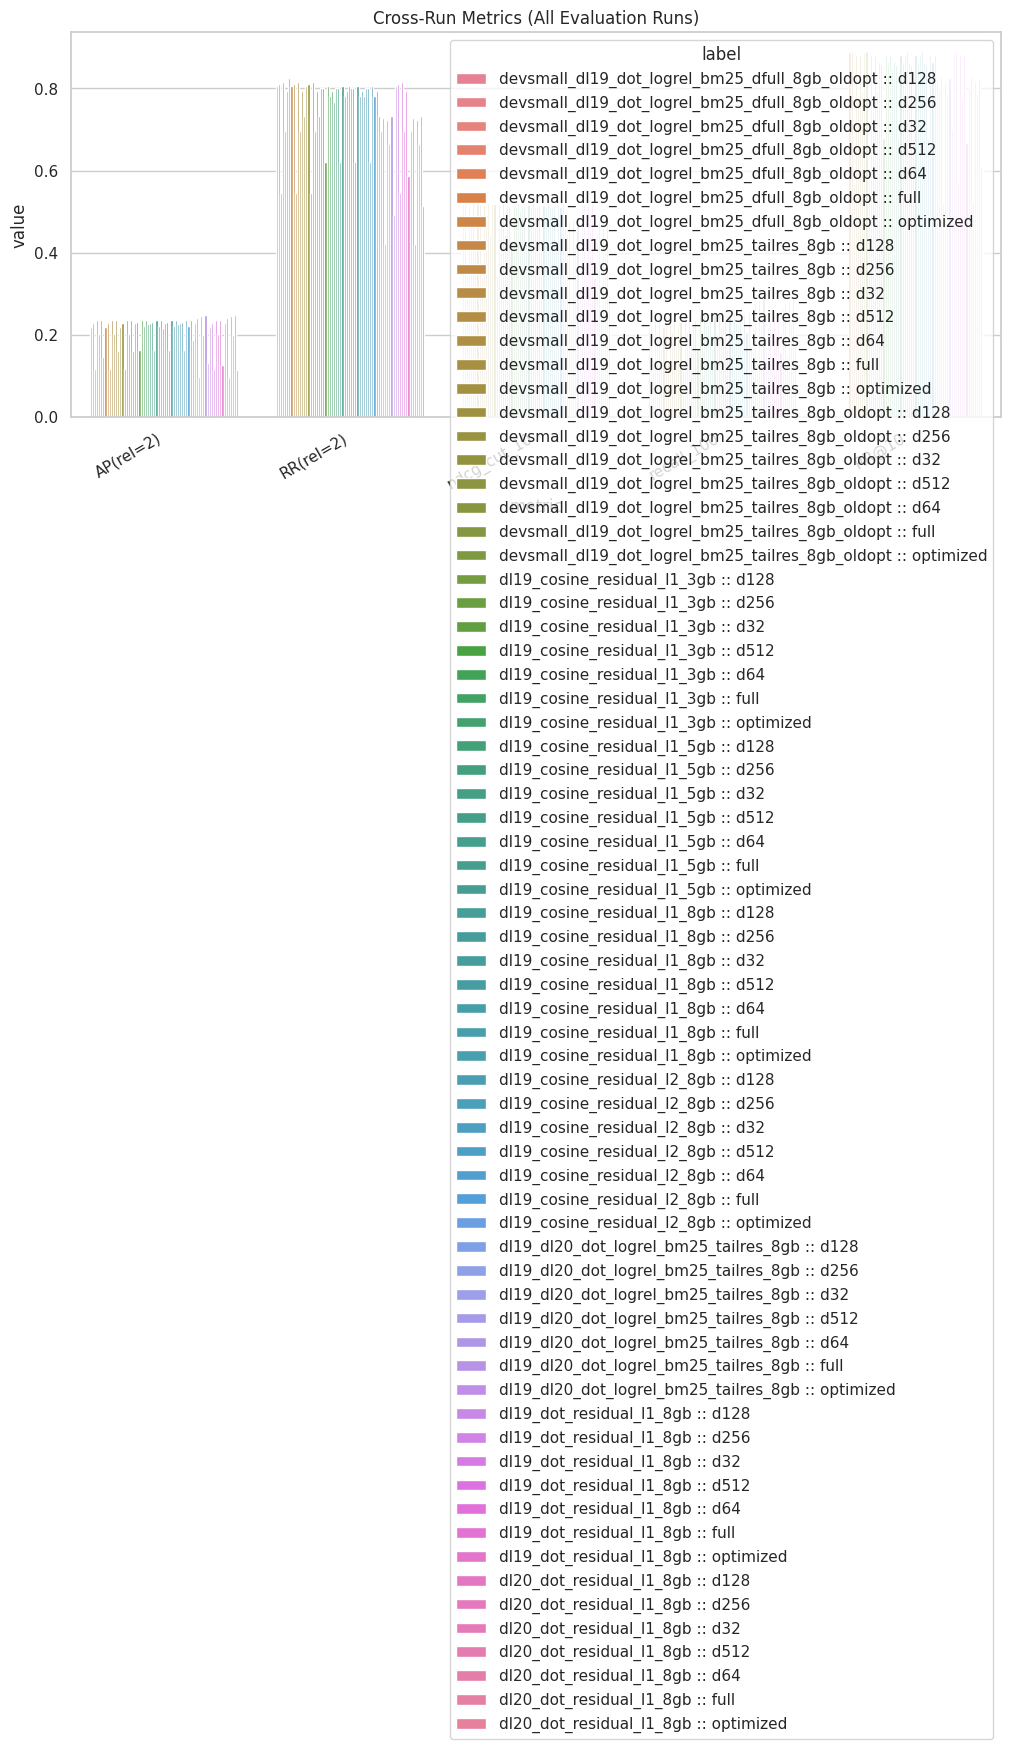

In [ ]:
if cross_summary.empty:
    print("No cross-run summary available.")
else:
    metric_cols = [c for c in cross_summary.columns if c.startswith("metric__") and not c.startswith("metric_delta_vs_baseline__")]
    if not metric_cols:
        print("No metric columns found.")
    else:
        id_col = "eval_run_name" if "eval_run_name" in cross_summary.columns else "experiment_run_name"
        melted = cross_summary.melt(id_vars=["experiment_run_name", id_col], value_vars=metric_cols, var_name="metric", value_name="value")
        melted["metric"] = melted["metric"].str.replace("metric__", "", regex=False)
        melted["label"] = melted["experiment_run_name"] + " :: " + melted[id_col].fillna("n/a")

        fig, ax = plt.subplots(figsize=(12, 5))
        if sns is not None:
            sns.barplot(data=melted, x="metric", y="value", hue="label", ax=ax)
        else:
            for label, grp in melted.groupby("label"):
                ax.plot(grp["metric"], grp["value"], marker="o", label=label)
            ax.legend()
        ax.set_title("Cross-Run Metrics (All Evaluation Runs)")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        _show_and_close(fig)

## Cross-Run Tradeoff Scatter

Plots memory savings versus the first available metric delta to visualize quality-memory tradeoffs.

In [ ]:
if cross_summary.empty:
    print("No cross-run summary available.")
else:
    delta_cols = [c for c in cross_summary.columns if c.startswith("metric_delta_vs_baseline__")]
    if not delta_cols:
        print("No baseline-delta metric columns found.")
    else:
        primary_delta = delta_cols[0]
        plot_df = cross_summary.dropna(subset=["memory_saved_pct", primary_delta]).copy()
        if plot_df.empty:
            print("Not enough data for tradeoff scatter.")
        else:
            fig, ax = plt.subplots(figsize=(8, 5))
            ax.scatter(plot_df["memory_saved_pct"], plot_df[primary_delta])
            labels = []
            for _, r in plot_df.iterrows():
                exp_name = r.get("experiment_run_name", "")
                eval_name = r.get("eval_run_name", "")
                label = f"{exp_name}::{eval_name}" if eval_name else exp_name
                labels.append(label)
                ax.annotate(label, (r["memory_saved_pct"], r[primary_delta]), fontsize=8)
            ax.set_title(f"Memory Saved vs {primary_delta.replace('metric_delta_vs_baseline__', '')} Delta")
            ax.set_xlabel("Memory saved (%)")
            ax.set_ylabel("Metric delta vs baseline")
            plt.tight_layout()
            _show_and_close(fig)

## Cross-Run Ranking Table

Shows runs ranked by the first available optimized metric (or delta metric when optimized metrics are unavailable).

In [ ]:
if cross_summary.empty:
    print("No cross-run summary available.")
else:
    metric_cols = [c for c in cross_summary.columns if c.startswith("metric__") and not c.startswith("metric_delta_vs_baseline__")]
    delta_cols = [c for c in cross_summary.columns if c.startswith("metric_delta_vs_baseline__")]

    ranking_col = metric_cols[0] if metric_cols else (delta_cols[0] if delta_cols else None)

    if ranking_col is None:
        print("No ranking metric column found.")
    else:
        cols = ["experiment_run_name", "eval_run_name", ranking_col, "memory_saved_pct", "optimized_total_utility"]
        cols = [c for c in cols if c in cross_summary.columns]
        ranking = cross_summary.sort_values(ranking_col, ascending=False)[cols]
        display(ranking)

,experiment_run_name,eval_run_name,metric__AP(rel=2),memory_saved_pct,optimized_total_utility
68,dl20_dot_residual_l1_8gb,full,0.2498,36.750540,5.960126e+06
54,dl19_dl20_dot_logrel_bm25_tailres_8gb,full,0.2498,36.750540,3.041670e+05
52,dl19_dl20_dot_logrel_bm25_tailres_8gb,d512,0.2452,36.750540,3.041670e+05
66,dl20_dot_residual_l1_8gb,d512,0.2452,36.750540,5.960126e+06
64,dl20_dot_residual_l1_8gb,d256,0.2409,36.750540,5.960126e+06
...,...,...,...,...,...
16,devsmall_dl19_dot_logrel_bm25_tailres_8gb_oldopt,d32,0.1180,36.765086,1.467360e+06
58,dl19_dot_residual_l1_8gb,d32,0.1180,36.750540,5.960126e+06
69,dl20_dot_residual_l1_8gb,optimized,0.1153,36.750540,5.960126e+06
51,dl19_dl20_dot_logrel_bm25_tailres_8gb,d32,0.0981,36.750540,3.041670e+05


## Export Dashboard Outputs

Exports manifest, cross-run summary, and artifact-specific plots to `analysis_viz/exports/<timestamp>/`.

In [ ]:
def export_dashboard_outputs(
    manifest_df: pd.DataFrame,
    cross_summary_df: pd.DataFrame,
    run_bundles_in: list[dict[str, Any]],
    export_root: Path,
) -> Path:
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = export_root / ts
    out_dir.mkdir(parents=True, exist_ok=True)

    manifest_df.to_csv(out_dir / "run_manifest.csv", index=False)
    cross_summary_df.to_csv(out_dir / "cross_run_summary.csv", index=False)

    for bundle in run_bundles_in:
        run_dir = out_dir / bundle["run_name"]
        run_dir.mkdir(parents=True, exist_ok=True)

        counts, _ = _assignment_profile_summary(bundle)
        if not counts.empty:
            counts = counts.sort_values(ascending=True)
            plot_counts = counts.clip(lower=1)
            fig, ax = plt.subplots(figsize=(10, max(4, 0.55 * len(counts) + 1.5)))
            bars = ax.barh(counts.index.astype(str), plot_counts.values)
            ax.set_xscale("log")
            ax.set_title(f"{bundle['run_name']} - Assigned Documents per Profile")
            ax.set_xlabel("Documents assigned (log scale)")
            total_docs = int(counts.sum())
            ax.set_xlim(0.8, max(float(plot_counts.max()), 1.0) * 8.0)
            for bar, count in zip(bars, counts.values):
                pct = (100.0 * count / total_docs) if total_docs else 0.0
                ax.text(max(float(count), 1.0) * 1.12, bar.get_y() + bar.get_height() / 2, f"{_format_count(count)} ({pct:.2f}%)", va="center", fontsize=9)
            plt.tight_layout()
            fig.savefig(run_dir / "assignments_profile_counts.png", dpi=150, bbox_inches="tight")
            plt.close(fig)
        del counts
        gc.collect()

        plot_data, utility_col, profile_col = _load_utility_plot_data(bundle, 10000)
        if not plot_data.empty and utility_col:
            fig, ax = plt.subplots(figsize=(11, 5))
            if profile_col:
                for profile_name, group in plot_data.groupby(profile_col, sort=True):
                    group = group.reset_index(drop=True)
                    ax.plot(group.index.values, group[utility_col].values, linewidth=1.0, label=str(profile_name))
                ax.legend(title="Profile", loc="best", fontsize=8)
            else:
                ax.plot(plot_data.index.values, plot_data[utility_col].values, linewidth=1.0, label="utility")
                ax.legend()
            ax.set_title(f"{bundle['run_name']} - Utility by Document")
            ax.set_xlabel("Document index")
            ax.set_ylabel(utility_col)
            plt.tight_layout()
            fig.savefig(run_dir / "utility_by_document.png", dpi=150, bbox_inches="tight")
            plt.close(fig)
        del plot_data
        gc.collect()

    return out_dir


if manifest.empty:
    print("Nothing to export yet because no runs were discovered.")
else:
    export_dir = export_dashboard_outputs(manifest_profiled, cross_summary, run_bundles, EXPORT_ROOT)
    print("Exported dashboard artifacts to:")
    print(export_dir)